# Current Progress

Completed so far:
- Step 0: Project foundation and README
- Step 1: Dataset download and folder setup
- Step 2: Raw data loading and dataset structure
- Step 3: Initial sales exploration
- Step 4: Overall sales trend over time
- Step 5: Category, state, and store trends
- Step 6: Event and SNAP effects
- Step 7A: Raw price analysis

Demand-type classification has not been done yet. ADI and CV² will be calculated in Step 11. Until then, all findings are aggregate-level observations.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# File paths
calendar_path = "../data/raw/calendar.csv"
sales_path = "../data/raw/sales_train_evaluation.csv"
prices_path = "../data/raw/sell_prices.csv"
sample_submission_path = "../data/raw/sample_submission.csv"

In [25]:
# Load raw data
calendar = pd.read_csv(calendar_path)
sales = pd.read_csv(sales_path)
prices = pd.read_csv(prices_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Data loaded successfully.")

Data loaded successfully.


In [16]:
print("Calendar shape:", calendar.shape)
print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)
print("Sample submission shape:", sample_submission.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Sample submission shape: (60980, 29)


In [17]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [18]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [19]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [20]:
sample_submission.head()

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
print("Calendar columns:")
print(calendar.columns.tolist())

print("\nSales columns first 15:")
print(sales.columns.tolist()[:15])

print("\nSales columns last 10:")
print(sales.columns.tolist()[-10:])

print("\nPrices columns:")
print(prices.columns.tolist())

print("\nSample submission columns first 10:")
print(sample_submission.columns.tolist()[:10])

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales columns first 15:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9']

Sales columns last 10:
['d_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']

Prices columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

Sample submission columns first 10:
['id', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']


In [22]:
print("Calendar info:")
calendar.info()

print("\nSales info:")
sales.info()

print("\nPrices info:")
prices.info()

Calendar info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB

Sales info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6

## Initial Dataset Understanding

The Walmart M5 dataset contains three main files required for this dissertation: sales data, calendar data, and price data.

The sales file contains 30,490 item-store time series. Each row represents one product sold in one store, and the daily sales columns run from d_1 to d_1941. This gives 1,941 days of historical unit sales for each item-store combination.

The calendar file contains 1,969 rows and maps each d_N value to a real date. It also includes calendar-related information such as weekday, month, year, events, event types, and SNAP indicators for different US states.

The sell prices file contains weekly selling prices for each item-store combination. It includes store_id, item_id, wm_yr_wk, and sell_price, which can later be merged with the sales and calendar data.

The sample submission file is mainly used for the Kaggle competition format and contains forecast columns F1 to F28. This confirms that the original competition used a 28-day forecast horizon.

In [26]:
print("Number of unique items:", sales["item_id"].nunique())
print("Number of unique departments:", sales["dept_id"].nunique())
print("Number of unique categories:", sales["cat_id"].nunique())
print("Number of unique stores:", sales["store_id"].nunique())
print("Number of unique states:", sales["state_id"].nunique())

print("\nStates:")
print(sales["state_id"].unique())

print("\nCategories:")
print(sales["cat_id"].unique())

print("\nDepartments:")
print(sales["dept_id"].unique())

print("\nStores:")
print(sales["store_id"].unique())

Number of unique items: 3049
Number of unique departments: 7
Number of unique categories: 3
Number of unique stores: 10
Number of unique states: 3

States:
['CA' 'TX' 'WI']

Categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']

Departments:
['HOBBIES_1' 'HOBBIES_2' 'HOUSEHOLD_1' 'HOUSEHOLD_2' 'FOODS_1' 'FOODS_2'
 'FOODS_3']

Stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


In [27]:
calendar["date"] = pd.to_datetime(calendar["date"])

print("Calendar start date:", calendar["date"].min())
print("Calendar end date:", calendar["date"].max())

sales_day_columns = [col for col in sales.columns if col.startswith("d_")]

print("Number of sales day columns:", len(sales_day_columns))
print("First sales day column:", sales_day_columns[0])
print("Last sales day column:", sales_day_columns[-1])

Calendar start date: 2011-01-29 00:00:00
Calendar end date: 2016-06-19 00:00:00
Number of sales day columns: 1941
First sales day column: d_1
Last sales day column: d_1941


In [28]:
print("Missing values in calendar:")
print(calendar.isnull().sum())

print("\nMissing values in sales identity columns:")
print(sales[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]].isnull().sum())

print("\nMissing values in prices:")
print(prices.isnull().sum())

Missing values in calendar:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Missing values in sales identity columns:
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64

Missing values in prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


## Dataset Structure Summary

The Walmart M5 dataset contains item-store level retail sales data across multiple stores, states, categories and departments.

The sales data contains 30,490 item-store time series. This comes from 3,049 unique items sold across 10 stores. Each row represents one item in one store, and the daily sales columns run from `d_1` to `d_1941`, giving 1,941 days of historical unit sales.

The dataset includes 3 states: California (CA), Texas (TX), and Wisconsin (WI). It contains 10 stores in total: CA_1, CA_2, CA_3, CA_4, TX_1, TX_2, TX_3, WI_1, WI_2, and WI_3.

There are 3 main product categories: HOBBIES, HOUSEHOLD, and FOODS. These are further divided into 7 departments: HOBBIES_1, HOBBIES_2, HOUSEHOLD_1, HOUSEHOLD_2, FOODS_1, FOODS_2, and FOODS_3.

The calendar file covers dates from 2011-01-29 to 2016-06-19 and maps each `d_N` value to a real date. It also contains weekday, month, year, event and SNAP-related information. The calendar file has 1,969 rows, while the sales file contains 1,941 daily sales columns. This is expected because the calendar includes additional future dates used for the forecasting horizon.

The sell prices file contains 6,841,121 rows and provides weekly selling prices for each item-store combination using `store_id`, `item_id`, `wm_yr_wk`, and `sell_price`.

Missing values in the calendar event columns are expected because most days do not contain special events. These missing event values will later be handled as “no event” rather than treated as data errors. The sales identity columns and sell price columns do not contain missing values.


# Step 3: Initial Sales Exploration

In this section, I explore the basic sales distribution in the Walmart M5 dataset before reshaping or modelling. The aim is to understand which categories, departments, states, and stores contribute most to total sales, and to examine how common zero-sales observations are across the item-store time series.

In [29]:
# Identify all daily sales columns
sales_day_columns = [col for col in sales.columns if col.startswith("d_")]

print("Number of daily sales columns:", len(sales_day_columns))
print("First 5 sales day columns:", sales_day_columns[:5])
print("Last 5 sales day columns:", sales_day_columns[-5:])

Number of daily sales columns: 1941
First 5 sales day columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5 sales day columns: ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']


In [30]:
# Total sales for each item-store time series
sales["total_sales"] = sales[sales_day_columns].sum(axis=1)

sales[["id", "item_id", "store_id", "cat_id", "dept_id", "state_id", "total_sales"]].head()

,id,item_id,store_id,cat_id,dept_id,state_id,total_sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,CA_1,HOBBIES,HOBBIES_1,CA,633
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,CA_1,HOBBIES,HOBBIES_1,CA,500
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,CA_1,HOBBIES,HOBBIES_1,CA,309
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,CA_1,HOBBIES,HOBBIES_1,CA,3337
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,CA_1,HOBBIES,HOBBIES_1,CA,1888


In [31]:
category_sales = (
    sales.groupby("cat_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

cat_id
FOODS        45922427
HOUSEHOLD    14764090
HOBBIES       6240656
Name: total_sales, dtype: int64

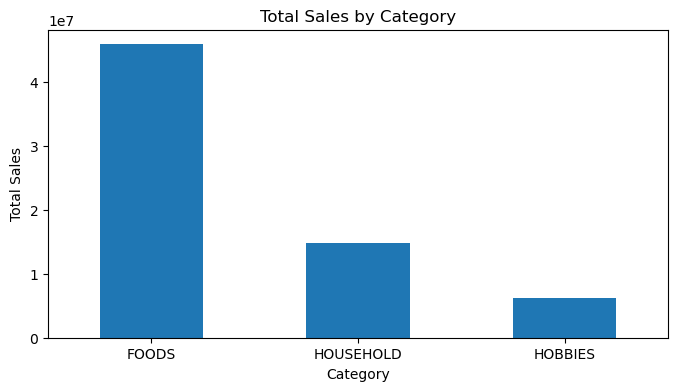

In [32]:
category_sales.plot(kind="bar", figsize=(8, 4), title="Total Sales by Category")

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [33]:
department_sales = (
    sales.groupby("dept_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

department_sales

dept_id
FOODS_3        32937002
HOUSEHOLD_1    11722853
FOODS_2         7795025
HOBBIES_1       5699014
FOODS_1         5190400
HOUSEHOLD_2     3041237
HOBBIES_2        541642
Name: total_sales, dtype: int64

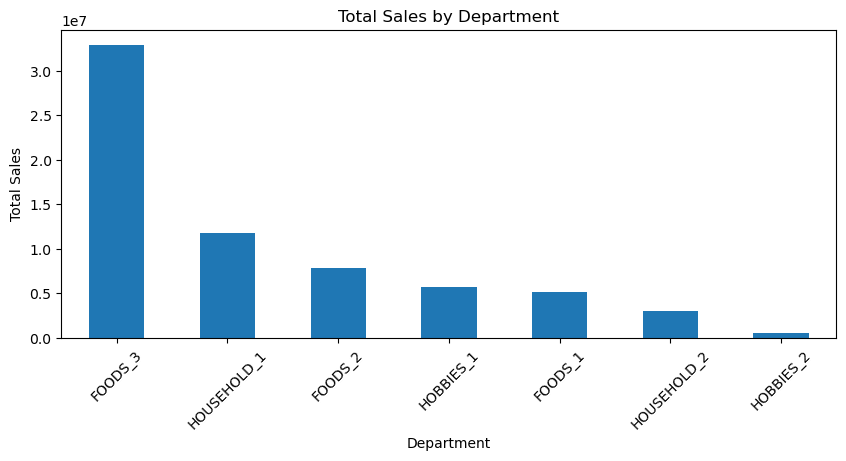

In [34]:
department_sales.plot(kind="bar", figsize=(10, 4), title="Total Sales by Department")

plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [35]:
state_sales = (
    sales.groupby("state_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales

state_id
CA    29196717
TX    19228405
WI    18502051
Name: total_sales, dtype: int64

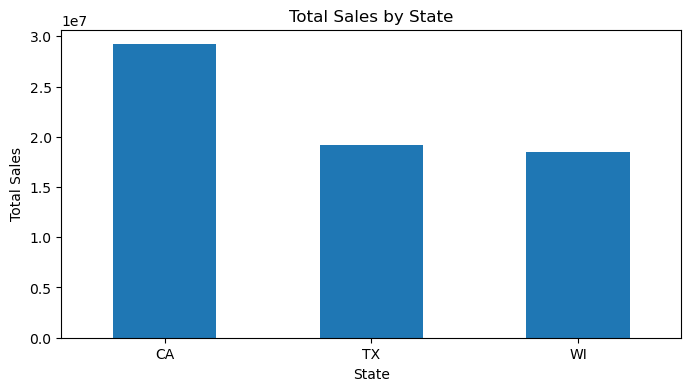

In [36]:
state_sales.plot(kind="bar", figsize=(8, 4), title="Total Sales by State")

plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [37]:
store_sales = (
    sales.groupby("store_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
CA_3    11363540
CA_1     7832248
TX_2     7329642
WI_2     6697988
WI_3     6542557
TX_3     6205940
CA_2     5818395
TX_1     5692823
WI_1     5261506
CA_4     4182534
Name: total_sales, dtype: int64

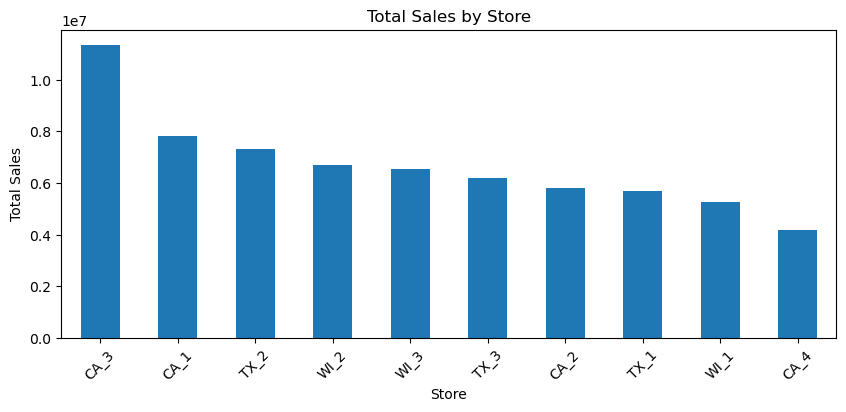

In [38]:
store_sales.plot(kind="bar", figsize=(10, 4), title="Total Sales by Store")

plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [39]:
total_values = sales[sales_day_columns].size
zero_values = (sales[sales_day_columns] == 0).sum().sum()

zero_percentage = (zero_values / total_values) * 100

print("Total sales observations:", total_values)
print("Zero sales observations:", zero_values)
print("Zero sales percentage:", round(zero_percentage, 2), "%")

Total sales observations: 59181090
Zero sales observations: 40241819
Zero sales percentage: 68.0 %


In [40]:
sales["zero_sales_count"] = (sales[sales_day_columns] == 0).sum(axis=1)
sales["zero_sales_percentage"] = (sales["zero_sales_count"] / len(sales_day_columns)) * 100

sales[[
    "id",
    "item_id",
    "store_id",
    "cat_id",
    "dept_id",
    "state_id",
    "total_sales",
    "zero_sales_percentage"
]].head()

,id,item_id,store_id,cat_id,dept_id,state_id,total_sales,zero_sales_percentage
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,CA_1,HOBBIES,HOBBIES_1,CA,633,77.537352
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,CA_1,HOBBIES,HOBBIES_1,CA,500,78.979907
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,CA_1,HOBBIES,HOBBIES_1,CA,309,88.201958
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,CA_1,HOBBIES,HOBBIES_1,CA,3337,32.199897
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,CA_1,HOBBIES,HOBBIES_1,CA,1888,49.356002


In [41]:
series_over_50_zero = (sales["zero_sales_percentage"] > 50).sum()
series_over_90_zero = (sales["zero_sales_percentage"] > 90).sum()

print("Series with more than 50% zero sales:", series_over_50_zero)
print("Percentage of all series:", round(series_over_50_zero / len(sales) * 100, 2), "%")

print("\nSeries with more than 90% zero sales:", series_over_90_zero)
print("Percentage of all series:", round(series_over_90_zero / len(sales) * 100, 2), "%")

Series with more than 50% zero sales: 23852
Percentage of all series: 78.23 %

Series with more than 90% zero sales: 5133
Percentage of all series: 16.84 %


In [42]:
# Top 10 item-store series by total sales
top_10_series = sales[[
    "id", "item_id", "store_id", "cat_id", "dept_id", "state_id", "total_sales", "zero_sales_percentage"
]].sort_values("total_sales", ascending=False).head(10)

top_10_series

,id,item_id,store_id,cat_id,dept_id,state_id,total_sales,zero_sales_percentage
8412,FOODS_3_090_CA_3_evaluation,FOODS_3_090,CA_3,FOODS,FOODS_3,CA,253859,18.495621
18055,FOODS_3_586_TX_2_evaluation,FOODS_3_586,TX_2,FOODS,FOODS_3,TX,195120,0.412159
21104,FOODS_3_586_TX_3_evaluation,FOODS_3_586,TX_3,FOODS,FOODS_3,TX,151862,0.360639
8908,FOODS_3_586_CA_3_evaluation,FOODS_3_586,CA_3,FOODS,FOODS_3,CA,136269,0.257599
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,CA_1,FOODS,FOODS_3,CA,128855,24.162803
29755,FOODS_3_090_WI_3_evaluation,FOODS_3_090,WI_3,FOODS,FOODS_3,WI,123500,25.090160
17559,FOODS_3_090_TX_2_evaluation,FOODS_3_090,TX_2,FOODS,FOODS_3,TX,121275,24.265842
20608,FOODS_3_090_TX_3_evaluation,FOODS_3_090,TX_3,FOODS,FOODS_3,TX,116773,24.317362
17721,FOODS_3_252_TX_2_evaluation,FOODS_3_252,TX_2,FOODS,FOODS_3,TX,115613,0.206079
15006,FOODS_3_586_TX_1_evaluation,FOODS_3_586,TX_1,FOODS,FOODS_3,TX,114010,0.721278


In [43]:
# Bottom 10 item-store series by total sales
bottom_10_series = sales[[
    "id", "item_id", "store_id", "cat_id", "dept_id", "state_id", "total_sales", "zero_sales_percentage"
]].sort_values("total_sales", ascending=True).head(10)

bottom_10_series

,id,item_id,store_id,cat_id,dept_id,state_id,total_sales,zero_sales_percentage
6048,FOODS_3_778_CA_2_evaluation,FOODS_3_778,CA_2,FOODS,FOODS_3,CA,15,99.381762
27606,HOBBIES_1_170_WI_3_evaluation,HOBBIES_1_170,WI_3,HOBBIES,HOBBIES_1,WI,16,99.175683
26276,FOODS_2_057_WI_2_evaluation,FOODS_2_057,WI_2,FOODS,FOODS_2,WI,16,99.278722
20192,FOODS_2_071_TX_3_evaluation,FOODS_2_071,TX_3,FOODS,FOODS_2,TX,18,99.175683
6682,HOUSEHOLD_1_020_CA_3_evaluation,HOUSEHOLD_1_020,CA_3,HOUSEHOLD,HOUSEHOLD_1,CA,23,99.124163
935,HOUSEHOLD_1_378_CA_1_evaluation,HOUSEHOLD_1_378,CA_1,HOUSEHOLD,HOUSEHOLD_1,CA,23,98.866564
10458,HOUSEHOLD_2_216_CA_4_evaluation,HOUSEHOLD_2_216,CA_4,HOUSEHOLD,HOUSEHOLD_2,CA,23,98.815044
6992,HOUSEHOLD_1_336_CA_3_evaluation,HOUSEHOLD_1_336,CA_3,HOUSEHOLD,HOUSEHOLD_1,CA,24,99.278722
10549,HOUSEHOLD_2_307_CA_4_evaluation,HOUSEHOLD_2_307,CA_4,HOUSEHOLD,HOUSEHOLD_2,CA,24,98.815044
17280,FOODS_2_209_TX_2_evaluation,FOODS_2_209,TX_2,FOODS,FOODS_2,TX,24,99.072643


In [44]:
category_sales.to_csv("../outputs/tables/category_sales_summary.csv")
department_sales.to_csv("../outputs/tables/department_sales_summary.csv")
state_sales.to_csv("../outputs/tables/state_sales_summary.csv")
store_sales.to_csv("../outputs/tables/store_sales_summary.csv")

print("Summary tables saved successfully.")

Summary tables saved successfully.


## Initial Sales Exploration — Interpretation

The initial sales exploration shows that total sales are not evenly distributed across categories, departments, states, or stores. The FOODS category accounts for the largest share of total sales, followed by HOUSEHOLD and HOBBIES. At department level, FOODS_3 is the dominant contributor, with substantially higher total sales than the other departments.

At state level, California has the highest overall sales, followed by Texas and Wisconsin. Store-level sales are also uneven, with CA_3 being the highest-selling store and CA_4 being the lowest-selling store in the dataset. This shows that demand behaviour varies not only by product category but also by geographic and store-level factors.

A key finding from this stage is the high level of zero-sales observations. Around 68% of all daily item-store sales observations are zero. In addition, 78.23% of item-store series have zero sales on more than half of the observed days, and 16.84% have zero sales on more than 90% of days.

This confirms that the dataset contains substantial demand sparsity. Therefore, it would be inappropriate to treat all item-store series as having the same demand behaviour. These findings support the need for a demand-type classification framework, where series can later be grouped into smooth, erratic, intermittent, and lumpy demand patterns before model comparison.


This finding will be revisited after demand classification in Step 11.

### Surprise Log

The strongest surprise was the scale of zero sales. 68.0% of all item-store-day observations are zero, and 78.23% of item-store series have zero sales on more than half of the observed days.

# Step 4: Overall Sales Trend Over Time

In this section, I examine how total sales change over time across the full Walmart M5 dataset. This helps identify broad trend, seasonality, sales spikes, and irregular patterns before moving into demand-type classification and forecasting.

In [45]:
# Create a dataframe of total sales for each day across all item-store series
daily_sales = sales[sales_day_columns].sum(axis=0).reset_index()

# Rename columns
daily_sales.columns = ["d", "total_sales"]

daily_sales.head()

,d,total_sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [46]:
# Merge daily total sales with calendar to get actual dates
daily_sales = daily_sales.merge(
    calendar[["d", "date", "weekday", "wday", "month", "year", "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]],
    on="d",
    how="left"
)

daily_sales.head()

,d,total_sales,date,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,Saturday,1,1,2011,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,Sunday,2,1,2011,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,Monday,3,1,2011,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,Tuesday,4,2,2011,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,Wednesday,5,2,2011,NaN,NaN,1,0,1


In [47]:
print("Daily sales start date:", daily_sales["date"].min())
print("Daily sales end date:", daily_sales["date"].max())
print("Number of days:", daily_sales.shape[0])

Daily sales start date: 2011-01-29 00:00:00
Daily sales end date: 2016-05-22 00:00:00
Number of days: 1941


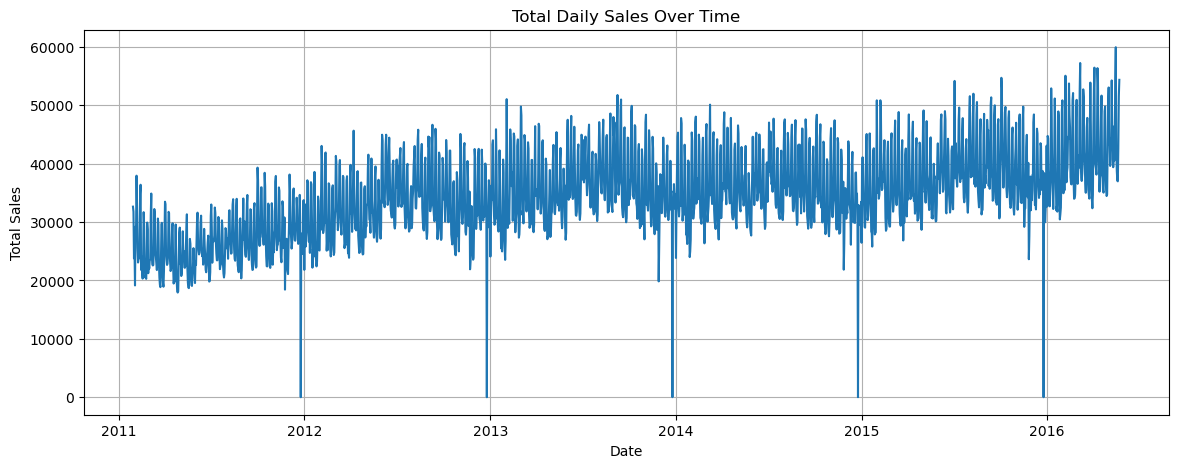

In [48]:
plt.figure(figsize=(14, 5))

plt.plot(daily_sales["date"], daily_sales["total_sales"])

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

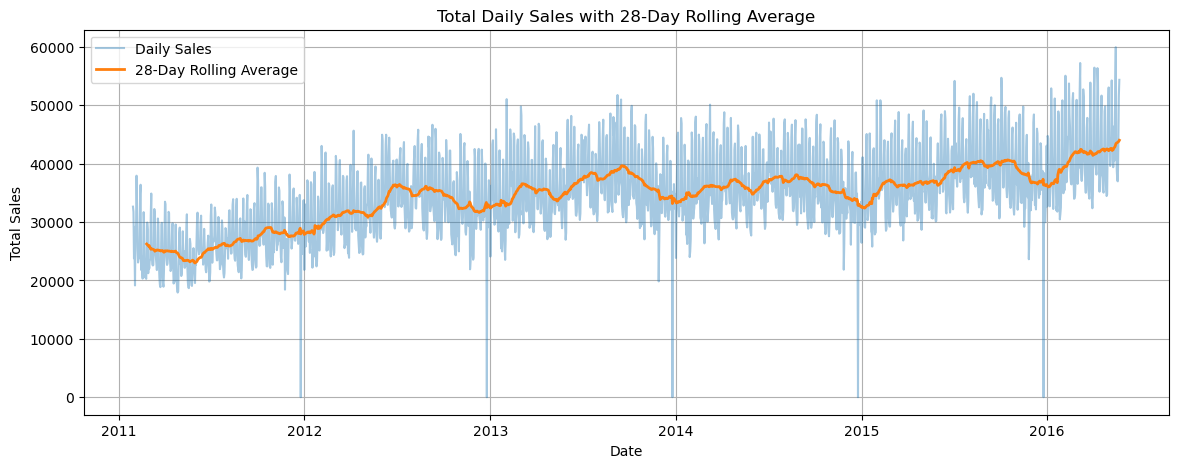

In [49]:
daily_sales["rolling_28_sales"] = daily_sales["total_sales"].rolling(window=28).mean()

plt.figure(figsize=(14, 5))

plt.plot(daily_sales["date"], daily_sales["total_sales"], alpha=0.4, label="Daily Sales")
plt.plot(daily_sales["date"], daily_sales["rolling_28_sales"], linewidth=2, label="28-Day Rolling Average")

plt.title("Total Daily Sales with 28-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# Set date as index for resampling
daily_sales_indexed = daily_sales.set_index("date")

# Weekly total sales
weekly_sales = daily_sales_indexed["total_sales"].resample("W").sum().reset_index()

weekly_sales.head()

,date,total_sales
0,2011-01-30,64380
1,2011-02-06,196230
2,2011-02-13,193715
3,2011-02-20,172328
4,2011-02-27,166645


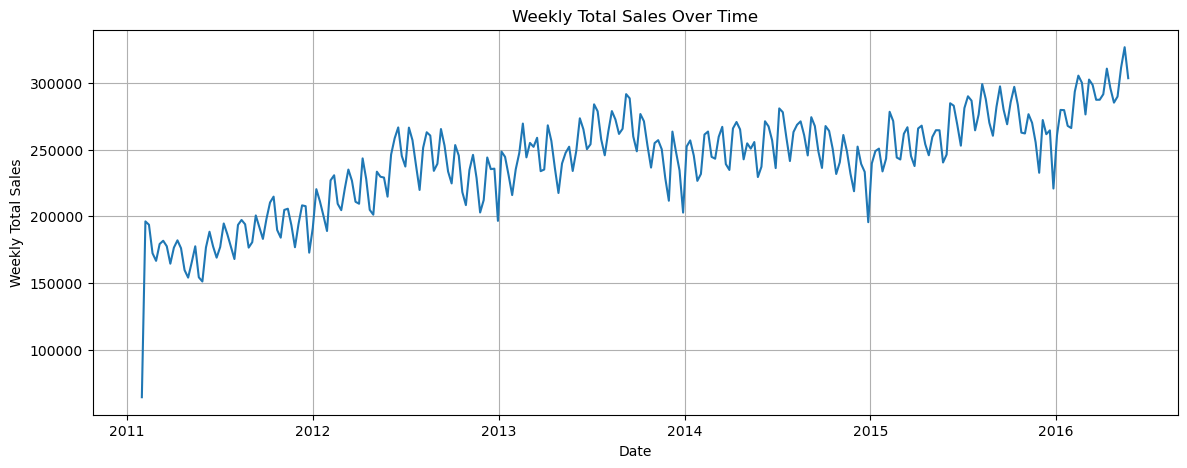

In [51]:
plt.figure(figsize=(14, 5))

plt.plot(weekly_sales["date"], weekly_sales["total_sales"])

plt.title("Weekly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Total Sales")
plt.grid(True)
plt.show()

In [52]:
monthly_sales = daily_sales_indexed["total_sales"].resample("M").sum().reset_index()

monthly_sales.head()

C:\Users\gamec\AppData\Local\Temp\ipykernel_46932\1102202795.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales_indexed["total_sales"].resample("M").sum().reset_index()


,date,total_sales
0,2011-01-31,88163
1,2011-02-28,726375
2,2011-03-31,763567
3,2011-04-30,737713
4,2011-05-31,719562


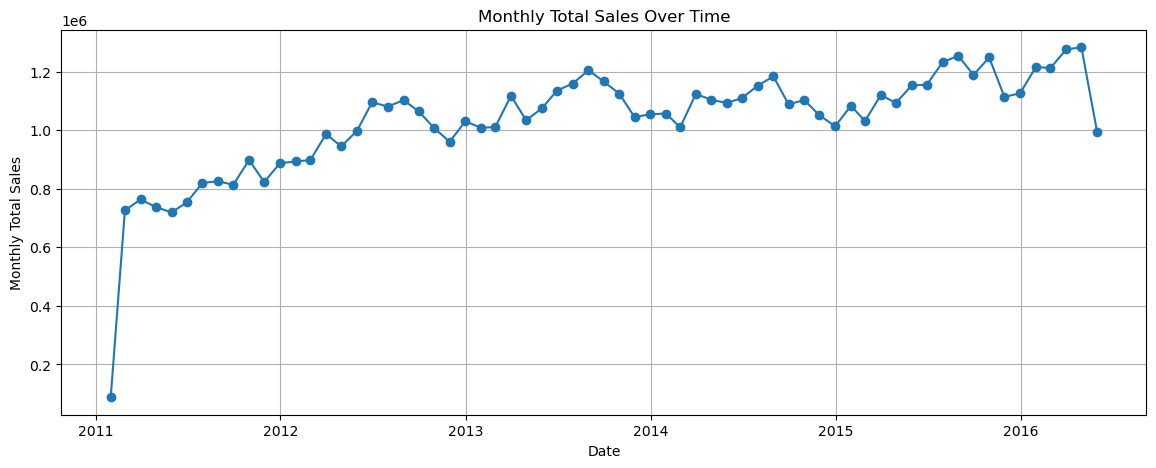

In [53]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales["date"], monthly_sales["total_sales"], marker="o")

plt.title("Monthly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Total Sales")
plt.grid(True)
plt.show()

In [54]:
weekday_sales = (
    daily_sales.groupby("weekday")["total_sales"]
    .mean()
    .sort_values(ascending=False)
)

weekday_sales

weekday
Saturday     41706.269784
Sunday       41304.050360
Friday       34357.472924
Monday       32994.931408
Tuesday      30500.483755
Thursday     30321.039711
Wednesday    30130.418773
Name: total_sales, dtype: float64

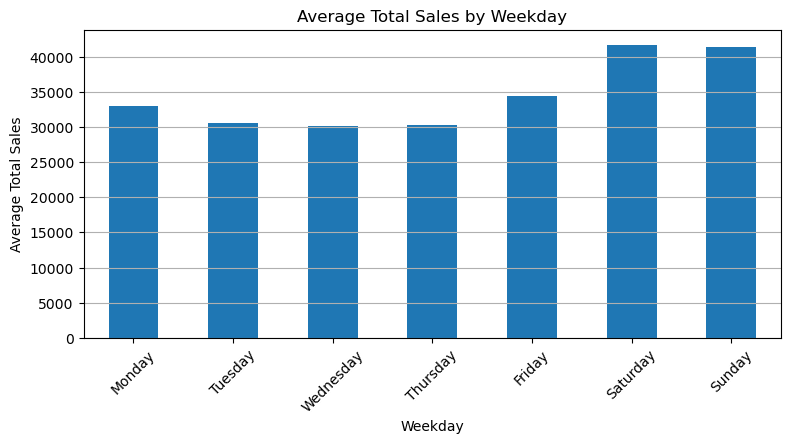

In [55]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_sales_ordered = daily_sales.groupby("weekday")["total_sales"].mean().reindex(weekday_order)

plt.figure(figsize=(9, 4))

weekday_sales_ordered.plot(kind="bar")

plt.title("Average Total Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [56]:
monthly_avg_sales = (
    daily_sales.groupby("month")["total_sales"]
    .mean()
)

monthly_avg_sales

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34432.183333
5     34085.192090
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: total_sales, dtype: float64

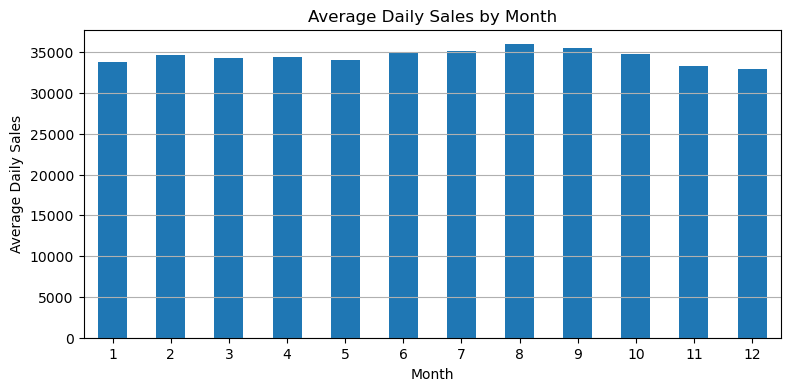

In [57]:
plt.figure(figsize=(9, 4))

monthly_avg_sales.plot(kind="bar")

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

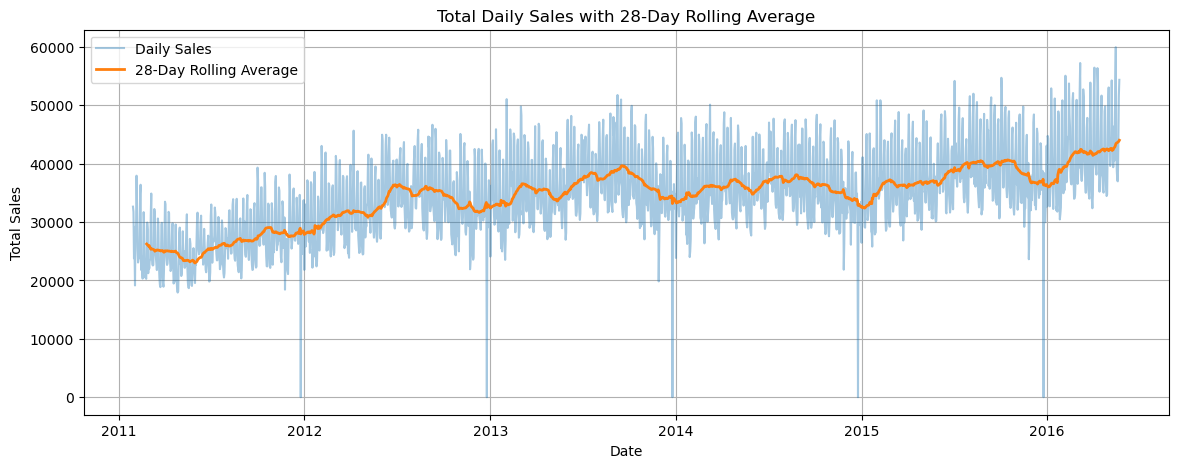

In [58]:
plt.figure(figsize=(14, 5))

plt.plot(daily_sales["date"], daily_sales["total_sales"], alpha=0.4, label="Daily Sales")
plt.plot(daily_sales["date"], daily_sales["rolling_28_sales"], linewidth=2, label="28-Day Rolling Average")

plt.title("Total Daily Sales with 28-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.savefig("../outputs/figures/total_daily_sales_rolling_28.png", dpi=300, bbox_inches="tight")
plt.show()

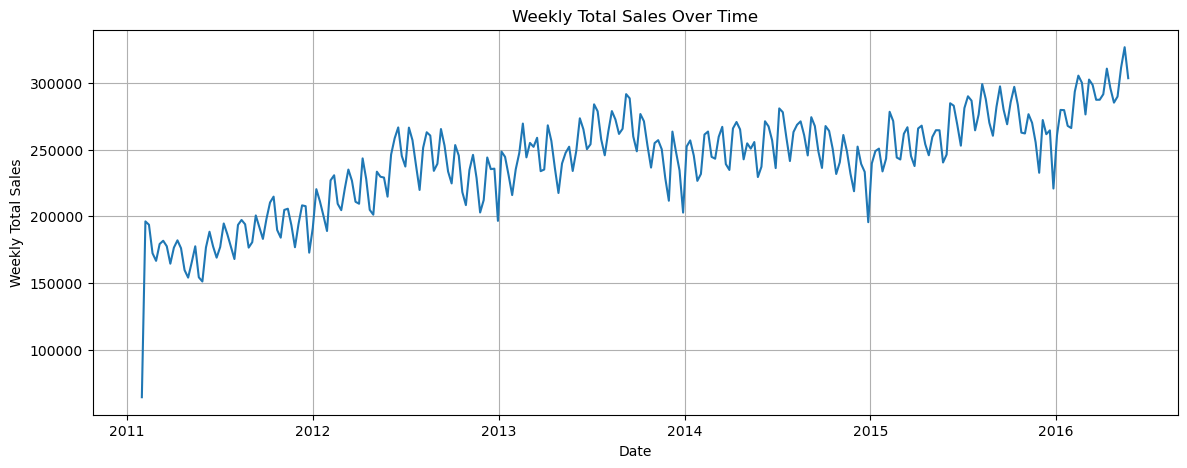

In [59]:
plt.figure(figsize=(14, 5))

plt.plot(weekly_sales["date"], weekly_sales["total_sales"])

plt.title("Weekly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Total Sales")
plt.grid(True)

plt.savefig("../outputs/figures/weekly_total_sales.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
daily_sales.to_csv("../outputs/tables/daily_total_sales.csv", index=False)
weekly_sales.to_csv("../outputs/tables/weekly_total_sales.csv", index=False)
monthly_sales.to_csv("../outputs/tables/monthly_total_sales.csv", index=False)
weekday_sales_ordered.to_csv("../outputs/tables/average_sales_by_weekday.csv")
monthly_avg_sales.to_csv("../outputs/tables/average_sales_by_month.csv")

print("Step 4 summary tables saved successfully.")

Step 4 summary tables saved successfully.


## Overall Sales Trend — Interpretation

The total daily sales data covers the period from 29 January 2011 to 22 May 2016, giving 1,941 days of historical sales observations. This matches the daily sales columns in the sales file, which run from `d_1` to `d_1941`.

The daily sales trend shows an overall increase toward the later part of the dataset, although there are frequent short-term ups and downs. This indicates that the aggregate retail sales series contains both longer-term movement and daily-level variability. Therefore, forecasting models need to account for general trend as well as short-term fluctuations.

The weekday analysis shows a clear weekly pattern. Average sales are highest on Saturday and Sunday, while Tuesday, Wednesday, and Thursday have the lowest average sales. This suggests that weekend shopping behaviour is important in the dataset. As a result, weekday-related features and weekly lag features such as `lag_7` are likely to be useful for forecasting.

The monthly analysis shows that average daily sales are highest around the summer months, especially July, August, and September, while November, December, and January show lower average daily sales. This suggests the presence of some monthly or seasonal variation, although the weekday effect appears more clearly pronounced at this stage.

Overall, this stage shows that the dataset contains time-based patterns that should be considered during feature engineering. In particular, weekday, weekend, monthly, and lag-based features are likely to be important for later machine learning models.


### Surprise Log

The clearest time-based pattern was the weekend effect. Saturday averages 41,706 daily units and Sunday averages 41,304, compared with 30,130 on Wednesday.

This finding will be revisited after demand classification in Step 11.

# Step 5: Category, State, and Store Sales Trends Over Time

In this section, I examine how total sales trends differ across product categories, states, and stores. This helps identify whether demand behaviour is consistent across the dataset or whether different parts of the retail hierarchy show different patterns over time.

In [117]:
# Daily total sales by category
category_daily_sales = sales.groupby("cat_id")[sales_day_columns].sum().T.reset_index()

# Rename first column
category_daily_sales = category_daily_sales.rename(columns={"index": "d"})

# Merge with calendar to get real dates
category_daily_sales = category_daily_sales.merge(
    calendar[["d", "date"]],
    on="d",
    how="left"
)

category_daily_sales.head()

,d,FOODS,HOBBIES,HOUSEHOLD,date
0,d_1,23178,3764,5689,2011-01-29
1,d_2,22758,3357,5634,2011-01-30
2,d_3,17174,2682,3927,2011-01-31
3,d_4,18878,2669,3865,2011-02-01
4,d_5,14603,1814,2729,2011-02-02


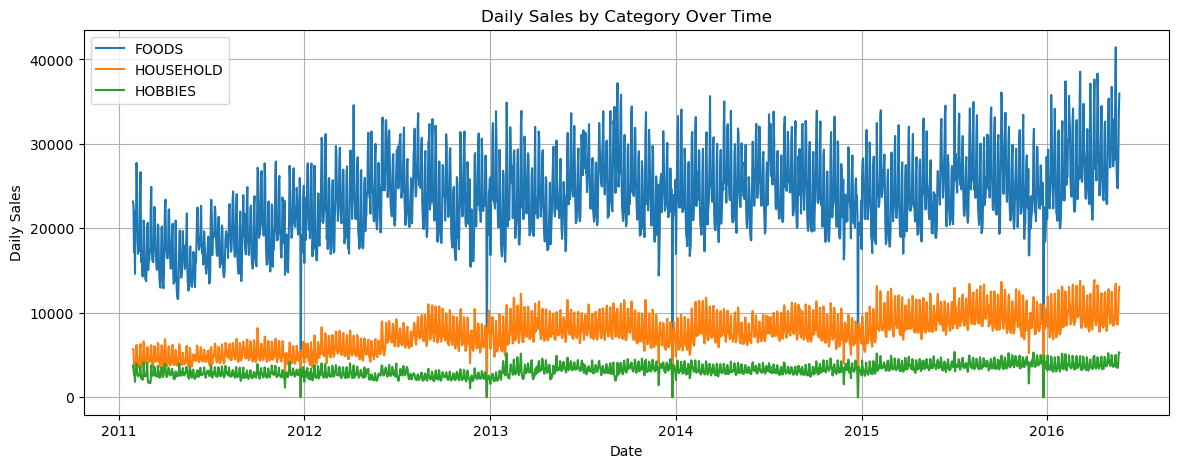

In [116]:
plt.figure(figsize=(14, 5))

plt.plot(category_daily_sales["date"], category_daily_sales["FOODS"], label="FOODS")
plt.plot(category_daily_sales["date"], category_daily_sales["HOUSEHOLD"], label="HOUSEHOLD")
plt.plot(category_daily_sales["date"], category_daily_sales["HOBBIES"], label="HOBBIES")

plt.title("Daily Sales by Category Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

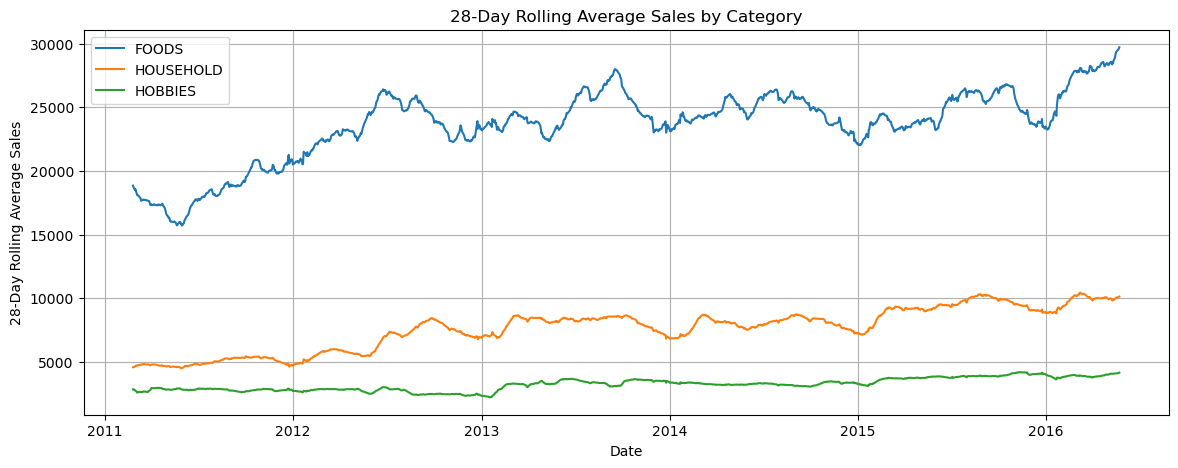

In [63]:
category_daily_sales["FOODS_rolling_28"] = category_daily_sales["FOODS"].rolling(window=28).mean()
category_daily_sales["HOUSEHOLD_rolling_28"] = category_daily_sales["HOUSEHOLD"].rolling(window=28).mean()
category_daily_sales["HOBBIES_rolling_28"] = category_daily_sales["HOBBIES"].rolling(window=28).mean()

plt.figure(figsize=(14, 5))

plt.plot(category_daily_sales["date"], category_daily_sales["FOODS_rolling_28"], label="FOODS")
plt.plot(category_daily_sales["date"], category_daily_sales["HOUSEHOLD_rolling_28"], label="HOUSEHOLD")
plt.plot(category_daily_sales["date"], category_daily_sales["HOBBIES_rolling_28"], label="HOBBIES")

plt.title("28-Day Rolling Average Sales by Category")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
category_average_daily_sales = category_daily_sales[["FOODS", "HOUSEHOLD", "HOBBIES"]].mean().sort_values(ascending=False)

category_average_daily_sales

FOODS        23659.158681
HOUSEHOLD     7606.434827
HOBBIES       3215.175683
dtype: float64

In [65]:
category_columns = ["FOODS", "HOUSEHOLD", "HOBBIES"]

first_90_category = category_daily_sales[category_columns].head(90).mean()
last_90_category = category_daily_sales[category_columns].tail(90).mean()

category_growth_summary = pd.DataFrame({
    "first_90_days_avg": first_90_category,
    "last_90_days_avg": last_90_category
})

category_growth_summary["absolute_change"] = (
    category_growth_summary["last_90_days_avg"] - category_growth_summary["first_90_days_avg"]
)

category_growth_summary["percentage_change"] = (
    category_growth_summary["absolute_change"] / category_growth_summary["first_90_days_avg"]
) * 100

category_growth_summary.sort_values("percentage_change", ascending=False)

,first_90_days_avg,last_90_days_avg,absolute_change,percentage_change
HOUSEHOLD,4661.344444,10065.711111,5404.366667,115.940084
FOODS,17726.133333,28543.888889,10817.755556,61.027159
HOBBIES,2778.988889,3952.311111,1173.322222,42.221192


In [66]:
# Daily total sales by state
state_daily_sales = sales.groupby("state_id")[sales_day_columns].sum().T.reset_index()

state_daily_sales = state_daily_sales.rename(columns={"index": "d"})

state_daily_sales = state_daily_sales.merge(
    calendar[["d", "date"]],
    on="d",
    how="left"
)

state_daily_sales.head()

,d,CA,TX,WI,date
0,d_1,14195,9438,8998,2011-01-29
1,d_2,13805,9630,8314,2011-01-30
2,d_3,10108,6778,6897,2011-01-31
3,d_4,11047,7381,6984,2011-02-01
4,d_5,9925,5912,3309,2011-02-02


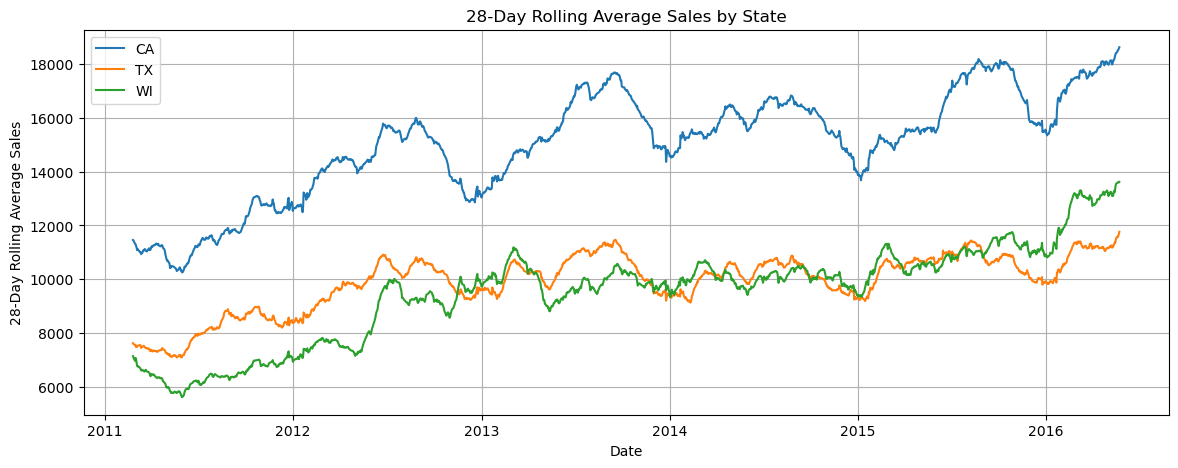

In [67]:
state_columns = ["CA", "TX", "WI"]

for state in state_columns:
    state_daily_sales[f"{state}_rolling_28"] = state_daily_sales[state].rolling(window=28).mean()

plt.figure(figsize=(14, 5))

plt.plot(state_daily_sales["date"], state_daily_sales["CA_rolling_28"], label="CA")
plt.plot(state_daily_sales["date"], state_daily_sales["TX_rolling_28"], label="TX")
plt.plot(state_daily_sales["date"], state_daily_sales["WI_rolling_28"], label="WI")

plt.title("28-Day Rolling Average Sales by State")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend()
plt.grid(True)
plt.show()

In [68]:
state_columns = ["CA", "TX", "WI"]

first_90_state = state_daily_sales[state_columns].head(90).mean()
last_90_state = state_daily_sales[state_columns].tail(90).mean()

state_growth_summary = pd.DataFrame({
    "first_90_days_avg": first_90_state,
    "last_90_days_avg": last_90_state
})

state_growth_summary["absolute_change"] = (
    state_growth_summary["last_90_days_avg"] - state_growth_summary["first_90_days_avg"]
)

state_growth_summary["percentage_change"] = (
    state_growth_summary["absolute_change"] / state_growth_summary["first_90_days_avg"]
) * 100

state_growth_summary.sort_values("percentage_change", ascending=False)

,first_90_days_avg,last_90_days_avg,absolute_change,percentage_change
WI,6569.077778,13194.177778,6625.100000,100.852817
CA,11163.700000,18043.044444,6879.344444,61.622441
TX,7433.688889,11324.688889,3891.000000,52.342788


In [69]:
# Daily total sales by store
store_daily_sales = sales.groupby("store_id")[sales_day_columns].sum().T.reset_index()

store_daily_sales = store_daily_sales.rename(columns={"index": "d"})

store_daily_sales = store_daily_sales.merge(
    calendar[["d", "date"]],
    on="d",
    how="left"
)

store_daily_sales.head()

,d,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3,date
0,d_1,4337,3494,4739,1625,2556,3852,3030,2704,2256,4038,2011-01-29
1,d_2,4155,3046,4827,1777,2687,3937,3006,2194,1922,4198,2011-01-30
2,d_3,2816,2121,3785,1386,1822,2731,2225,1562,2018,3317,2011-01-31
3,d_4,3051,2324,4232,1440,2258,2954,2169,1251,2522,3211,2011-02-01
4,d_5,2630,1942,3817,1536,1694,2492,1726,2,1175,2132,2011-02-02


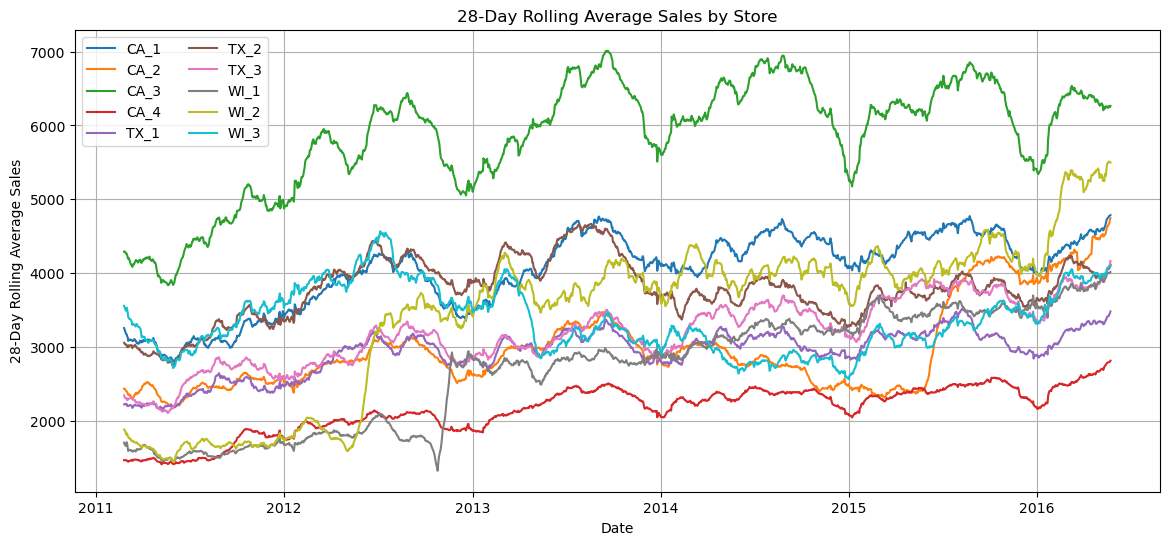

In [70]:
store_columns = ["CA_1", "CA_2", "CA_3", "CA_4", "TX_1", "TX_2", "TX_3", "WI_1", "WI_2", "WI_3"]

for store in store_columns:
    store_daily_sales[f"{store}_rolling_28"] = store_daily_sales[store].rolling(window=28).mean()

plt.figure(figsize=(14, 6))

for store in store_columns:
    plt.plot(store_daily_sales["date"], store_daily_sales[f"{store}_rolling_28"], label=store)

plt.title("28-Day Rolling Average Sales by Store")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [76]:
first_90_store = store_daily_sales[store_columns].head(90).mean()
last_90_store = store_daily_sales[store_columns].tail(90).mean()

store_growth_summary = pd.DataFrame({
    "first_90_days_avg": first_90_store,
    "last_90_days_avg": last_90_store
})

store_growth_summary["absolute_change"] = (
    store_growth_summary["last_90_days_avg"] - store_growth_summary["first_90_days_avg"]
)

store_growth_summary["percentage_change"] = (
    store_growth_summary["absolute_change"] / store_growth_summary["first_90_days_avg"]
) * 100

store_growth_summary.sort_values("percentage_change", ascending=False)

,first_90_days_avg,last_90_days_avg,absolute_change,percentage_change
WI_2,1701.288889,5336.422222,3635.133333,213.669375
WI_1,1619.177778,3874.288889,2255.111111,139.275078
CA_2,2419.488889,4432.688889,2013.200000,83.207656
CA_4,1466.922222,2674.122222,1207.200000,82.294752
TX_3,2262.966667,3913.644444,1650.677778,72.943088
CA_3,4171.422222,6344.844444,2173.422222,52.102667
TX_1,2205.544444,3346.633333,1141.088889,51.737288
CA_1,3105.866667,4591.388889,1485.522222,47.829556
TX_2,2965.177778,4064.411111,1099.233333,37.071414
WI_3,3248.611111,3983.466667,734.855556,22.620607


In [72]:
# Save tables
category_daily_sales.to_csv("../outputs/tables/category_daily_sales.csv", index=False)
state_daily_sales.to_csv("../outputs/tables/state_daily_sales.csv", index=False)
store_daily_sales.to_csv("../outputs/tables/store_daily_sales.csv", index=False)

category_growth_summary.to_csv("../outputs/tables/category_growth_summary.csv")
state_growth_summary.to_csv("../outputs/tables/state_growth_summary.csv")
store_growth_summary.to_csv("../outputs/tables/store_growth_summary.csv")

print("Step 5 tables saved successfully.")

Step 5 tables saved successfully.


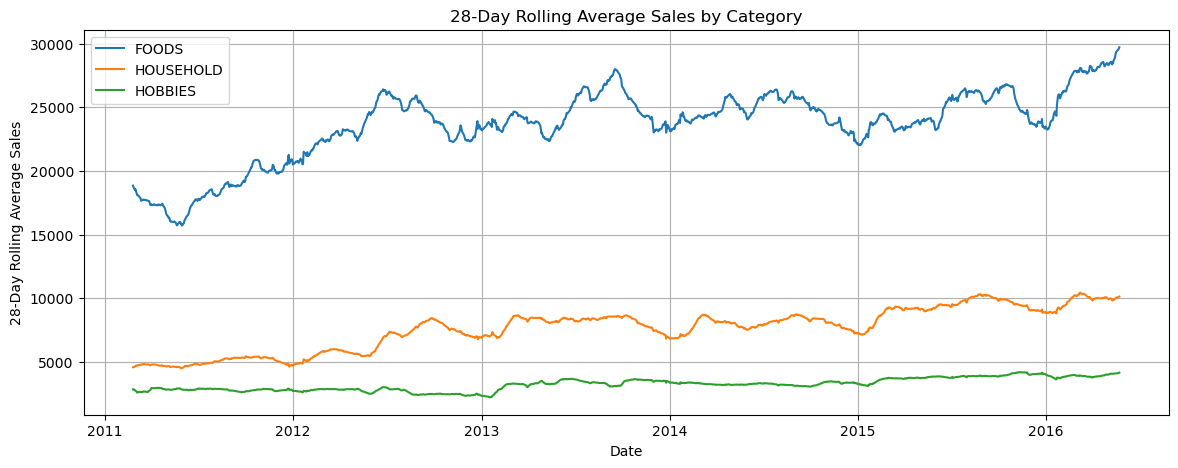

In [73]:
plt.figure(figsize=(14, 5))

plt.plot(category_daily_sales["date"], category_daily_sales["FOODS_rolling_28"], label="FOODS")
plt.plot(category_daily_sales["date"], category_daily_sales["HOUSEHOLD_rolling_28"], label="HOUSEHOLD")
plt.plot(category_daily_sales["date"], category_daily_sales["HOBBIES_rolling_28"], label="HOBBIES")

plt.title("28-Day Rolling Average Sales by Category")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend()
plt.grid(True)

plt.savefig("../outputs/figures/category_sales_rolling_28.png", dpi=300, bbox_inches="tight")
plt.show()

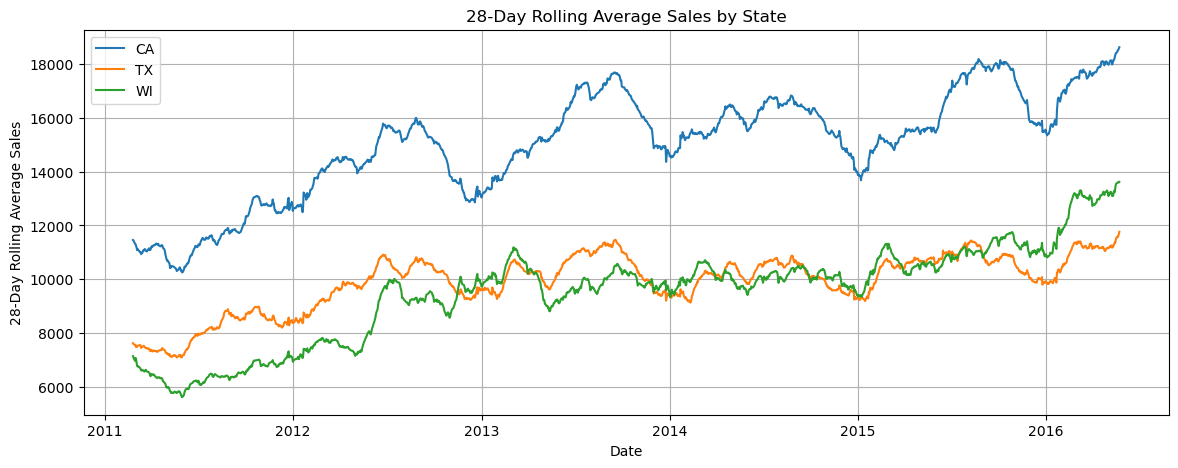

In [74]:
plt.figure(figsize=(14, 5))

plt.plot(state_daily_sales["date"], state_daily_sales["CA_rolling_28"], label="CA")
plt.plot(state_daily_sales["date"], state_daily_sales["TX_rolling_28"], label="TX")
plt.plot(state_daily_sales["date"], state_daily_sales["WI_rolling_28"], label="WI")

plt.title("28-Day Rolling Average Sales by State")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend()
plt.grid(True)

plt.savefig("../outputs/figures/state_sales_rolling_28.png", dpi=300, bbox_inches="tight")
plt.show()

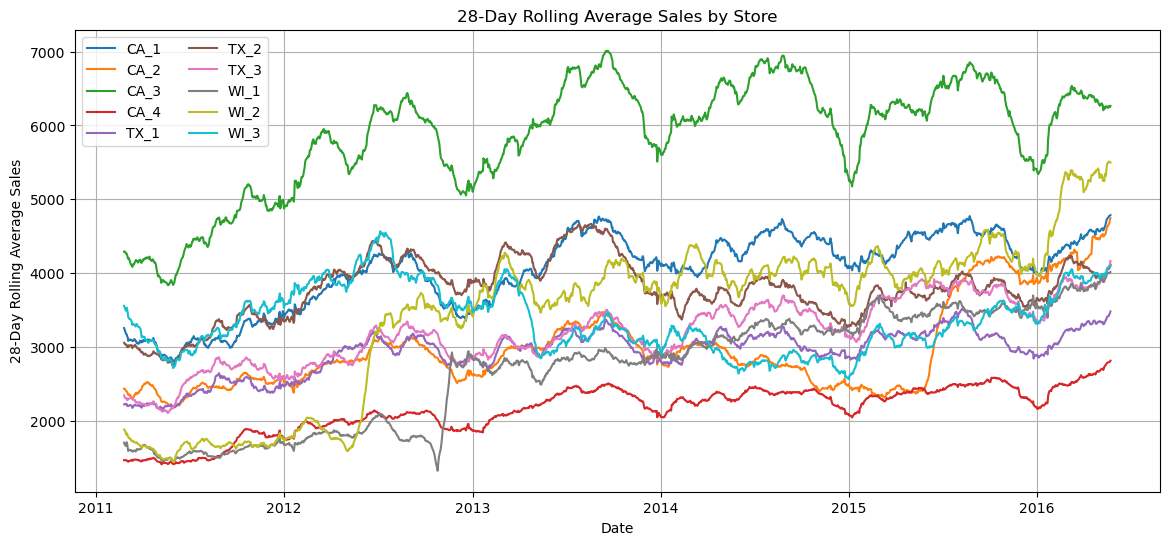

In [75]:
plt.figure(figsize=(14, 6))

for store in store_columns:
    plt.plot(store_daily_sales["date"], store_daily_sales[f"{store}_rolling_28"], label=store)

plt.title("28-Day Rolling Average Sales by Store")
plt.xlabel("Date")
plt.ylabel("28-Day Rolling Average Sales")
plt.legend(ncol=2)
plt.grid(True)

plt.savefig("../outputs/figures/store_sales_rolling_28.png", dpi=300, bbox_inches="tight")
plt.show()

## Category, State, and Store Trend Interpretation

The category-level trend analysis shows that FOODS has the highest average daily sales throughout the dataset, confirming that it is the dominant category by sales volume. However, the first-90-days versus last-90-days comparison shows that HOUSEHOLD has the strongest relative growth, increasing by approximately 115.94%. FOODS also grows substantially, with a 61.03% increase, while HOBBIES shows a smaller increase of 42.22%.

At state level, California has the highest overall sales volume, but Wisconsin shows the strongest relative growth. The average daily sales in Wisconsin increase from approximately 6,569 units in the first 90 days to 13,194 units in the last 90 days, representing a 100.85% increase. This suggests that states with lower initial sales can still show strong growth over time.

The store-level analysis shows further variation. CA_3 appears to be one of the strongest stores by overall sales volume, while CA_4 has relatively lower sales. However, the growth comparison shows that WI_2 has the strongest relative increase, rising from approximately 1,701 average daily units in the first 90 days to 5,336 average daily units in the last 90 days. This is a 213.67% increase, making WI_2 the fastest-growing store in this comparison.

These findings show that demand behaviour differs across categories, states, and stores. High total sales volume does not always correspond to the highest growth rate. This supports the need for a demand heterogeneity approach, because different parts of the retail hierarchy show different sales patterns over time.


### Surprise Log

WI_2 has the strongest store-level growth, increasing by 213.67% from the first 90 days to the last 90 days. This is different from the volume ranking, where CA_3 remains one of the strongest stores.

This finding will be revisited after demand classification in Step 11.

# Step 6: Event and SNAP Effects on Sales

In this section, I examine whether total sales differ between event and non-event days, and whether SNAP-related calendar indicators are associated with changes in sales. This is useful because event and SNAP features may later be included in the forecasting models.

In [77]:
calendar[[
    "date",
    "d",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]].head(10)

,date,d,event_name_1,event_type_1,event_name_2,event_type_2
0,2011-01-29,d_1,NaN,NaN,NaN,NaN
1,2011-01-30,d_2,NaN,NaN,NaN,NaN
2,2011-01-31,d_3,NaN,NaN,NaN,NaN
3,2011-02-01,d_4,NaN,NaN,NaN,NaN
4,2011-02-02,d_5,NaN,NaN,NaN,NaN
5,2011-02-03,d_6,NaN,NaN,NaN,NaN
6,2011-02-04,d_7,NaN,NaN,NaN,NaN
7,2011-02-05,d_8,NaN,NaN,NaN,NaN
8,2011-02-06,d_9,SuperBowl,Sporting,NaN,NaN
9,2011-02-07,d_10,NaN,NaN,NaN,NaN


In [78]:
print("Event name 1 counts:")
print(calendar["event_name_1"].value_counts(dropna=False).head(20))

print("\nEvent type 1 counts:")
print(calendar["event_type_1"].value_counts(dropna=False))

print("\nEvent name 2 counts:")
print(calendar["event_name_2"].value_counts(dropna=False).head(20))

print("\nEvent type 2 counts:")
print(calendar["event_type_2"].value_counts(dropna=False))

Event name 1 counts:
event_name_1
NaN                1807
SuperBowl             6
ValentinesDay         6
PresidentsDay         6
LentStart             6
LentWeek2             6
StPatricksDay         6
Purim End             6
Pesach End            6
MemorialDay           6
Mother's day          6
NBAFinalsStart        6
NBAFinalsEnd          6
Ramadan starts        6
Cinco De Mayo         5
OrthodoxEaster        5
IndependenceDay       5
Eid al-Fitr           5
LaborDay              5
Halloween             5
Name: count, dtype: int64

Event type 1 counts:
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

Event name 2 counts:
event_name_2
NaN               1964
Father's day         2
Easter               1
Cinco De Mayo        1
OrthodoxEaster       1
Name: count, dtype: int64

Event type 2 counts:
event_type_2
NaN          1964
Cultural        4
Religious       1
Name: count, dtype: int64


In [79]:
# Create event flags
daily_sales["has_event_1"] = daily_sales["event_name_1"].notna().astype(int)
daily_sales["has_event"] = daily_sales["has_event_1"]

# If event_name_2 exists in daily_sales, include it too
if "event_name_2" in daily_sales.columns:
    daily_sales["has_event_2"] = daily_sales["event_name_2"].notna().astype(int)
    daily_sales["has_event"] = ((daily_sales["has_event_1"] == 1) | (daily_sales["has_event_2"] == 1)).astype(int)

daily_sales[["date", "total_sales", "event_name_1", "event_type_1", "has_event"]].head()

,date,total_sales,event_name_1,event_type_1,has_event
0,2011-01-29,32631,NaN,NaN,0
1,2011-01-30,31749,NaN,NaN,0
2,2011-01-31,23783,NaN,NaN,0
3,2011-02-01,25412,NaN,NaN,0
4,2011-02-02,19146,NaN,NaN,0


In [80]:
# Rebuild daily_sales event information safely
daily_sales = daily_sales.drop(columns=["event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"], errors="ignore")

daily_sales = daily_sales.merge(
    calendar[[
        "d",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]],
    on="d",
    how="left"
)

daily_sales["has_event_1"] = daily_sales["event_name_1"].notna().astype(int)
daily_sales["has_event_2"] = daily_sales["event_name_2"].notna().astype(int)
daily_sales["has_event"] = ((daily_sales["has_event_1"] == 1) | (daily_sales["has_event_2"] == 1)).astype(int)

daily_sales.head()

,d,total_sales,date,weekday,wday,month,year,rolling_28_sales,has_event_1,has_event,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event_2
0,d_1,32631,2011-01-29,Saturday,1,1,2011,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0,0
1,d_2,31749,2011-01-30,Sunday,2,1,2011,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0,0
2,d_3,23783,2011-01-31,Monday,3,1,2011,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0,0
3,d_4,25412,2011-02-01,Tuesday,4,2,2011,NaN,0,0,NaN,NaN,NaN,NaN,1,1,0,0
4,d_5,19146,2011-02-02,Wednesday,5,2,2011,NaN,0,0,NaN,NaN,NaN,NaN,1,0,1,0


In [81]:
event_sales_summary = daily_sales.groupby("has_event")["total_sales"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)

event_sales_summary

,count,mean,median,std,min,max
has_event,,,,,,
0,1783,34609.336511,33817.0,7202.360245,17929,59921
1,158,33029.911392,33956.5,9502.940436,11,53032


In [82]:
non_event_mean = event_sales_summary.loc[0, "mean"]
event_mean = event_sales_summary.loc[1, "mean"]

event_percentage_difference = ((event_mean - non_event_mean) / non_event_mean) * 100

print("Average sales on non-event days:", round(non_event_mean, 2))
print("Average sales on event days:", round(event_mean, 2))
print("Percentage difference:", round(event_percentage_difference, 2), "%")

Average sales on non-event days: 34609.34
Average sales on event days: 33029.91
Percentage difference: -4.56 %


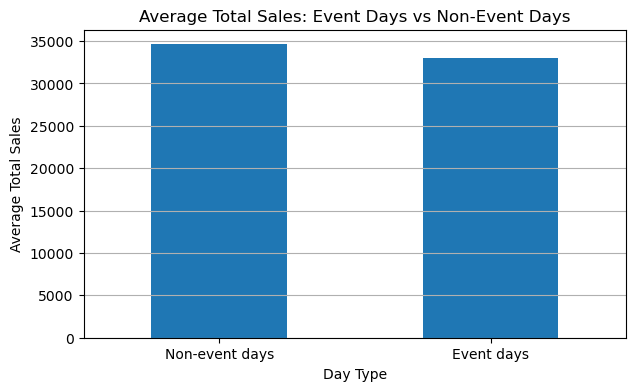

In [83]:
event_mean_sales = daily_sales.groupby("has_event")["total_sales"].mean()

event_mean_sales.index = ["Non-event days", "Event days"]

plt.figure(figsize=(7, 4))
event_mean_sales.plot(kind="bar")

plt.title("Average Total Sales: Event Days vs Non-Event Days")
plt.xlabel("Day Type")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [84]:
event_type_sales = (
    daily_sales.dropna(subset=["event_type_1"])
    .groupby("event_type_1")["total_sales"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

event_type_sales

,count,mean,median,std
event_type_1,,,,
Sporting,16,35796.062500,34998.0,6651.926533
Cultural,37,34718.594595,35820.0,7481.756287
Religious,54,34426.240741,34214.0,7738.967492
National,51,29458.509804,32656.0,12117.064001


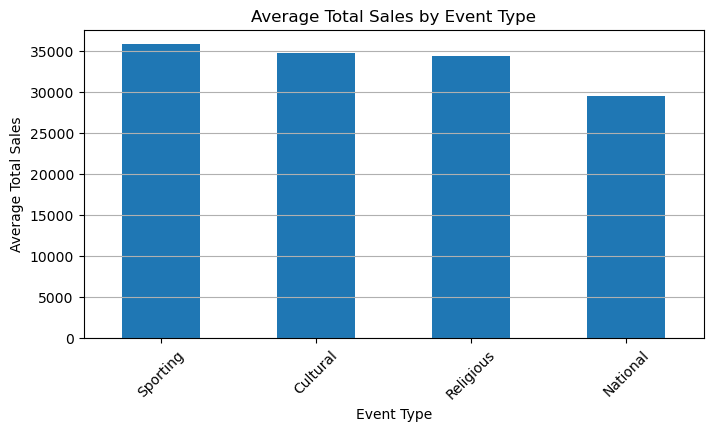

In [85]:
plt.figure(figsize=(8, 4))

event_type_sales["mean"].plot(kind="bar")

plt.title("Average Total Sales by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [86]:
event_name_sales = (
    daily_sales.dropna(subset=["event_name_1"])
    .groupby("event_name_1")["total_sales"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean", ascending=False)
)

event_name_sales.head(15)

,count,mean,median
event_name_1,,,
LaborDay,5,42154.600000,44525.0
OrthodoxEaster,5,41228.000000,43203.0
SuperBowl,6,40924.000000,40971.5
Easter,5,39517.600000,38934.0
Father's day,4,36562.000000,39364.5
Pesach End,6,36280.000000,36594.0
Mother's day,6,36111.000000,37710.0
Purim End,6,35957.000000,33411.0
Eid al-Fitr,5,35267.600000,34886.0


In [88]:
# Add SNAP indicators to state-level daily sales
state_snap_sales = state_daily_sales.merge(
    calendar[["d", "snap_CA", "snap_TX", "snap_WI"]],
    on="d",
    how="left"
)

state_snap_sales.head()

,d,CA,TX,WI,date,CA_rolling_28,TX_rolling_28,WI_rolling_28,snap_CA,snap_TX,snap_WI
0,d_1,14195,9438,8998,2011-01-29,NaN,NaN,NaN,0,0,0
1,d_2,13805,9630,8314,2011-01-30,NaN,NaN,NaN,0,0,0
2,d_3,10108,6778,6897,2011-01-31,NaN,NaN,NaN,0,0,0
3,d_4,11047,7381,6984,2011-02-01,NaN,NaN,NaN,1,1,0
4,d_5,9925,5912,3309,2011-02-02,NaN,NaN,NaN,1,0,1


In [89]:
snap_summary = []

state_snap_mapping = {
    "CA": "snap_CA",
    "TX": "snap_TX",
    "WI": "snap_WI"
}

for state, snap_col in state_snap_mapping.items():
    temp = state_snap_sales.groupby(snap_col)[state].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    ).reset_index()
    
    non_snap_mean = temp.loc[temp[snap_col] == 0, "mean"].values[0]
    snap_mean = temp.loc[temp[snap_col] == 1, "mean"].values[0]
    
    percentage_difference = ((snap_mean - non_snap_mean) / non_snap_mean) * 100
    
    snap_summary.append({
        "state": state,
        "non_snap_mean_sales": non_snap_mean,
        "snap_mean_sales": snap_mean,
        "percentage_difference": percentage_difference
    })

snap_summary = pd.DataFrame(snap_summary)

snap_summary

,state,non_snap_mean_sales,snap_mean_sales,percentage_difference
0,CA,14657.744812,15823.423437,7.952646
1,TX,9543.856264,10643.512500,11.522137
2,WI,8892.503459,10832.662500,21.817917


<Figure size 800x400 with 0 Axes>

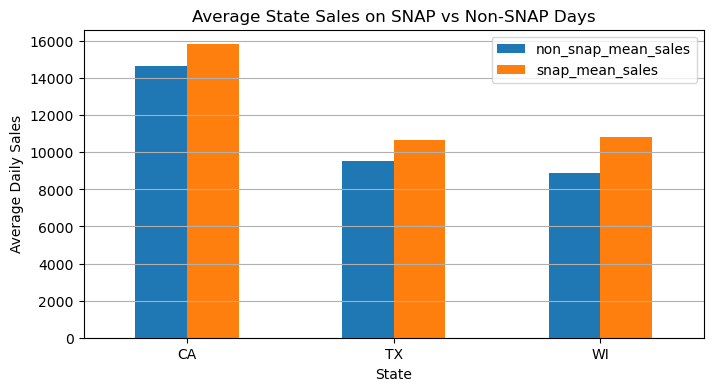

In [90]:
snap_plot_data = snap_summary.set_index("state")[["non_snap_mean_sales", "snap_mean_sales"]]

plt.figure(figsize=(8, 4))

snap_plot_data.plot(kind="bar", figsize=(8, 4))

plt.title("Average State Sales on SNAP vs Non-SNAP Days")
plt.xlabel("State")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [91]:
event_sales_summary.to_csv("../outputs/tables/event_sales_summary.csv")
event_type_sales.to_csv("../outputs/tables/event_type_sales_summary.csv")
event_name_sales.to_csv("../outputs/tables/event_name_sales_summary.csv")
snap_summary.to_csv("../outputs/tables/snap_sales_summary.csv", index=False)

print("Step 6 tables saved successfully.")

Step 6 tables saved successfully.


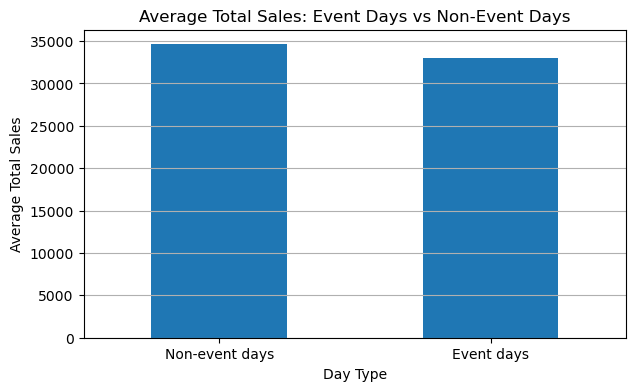

In [92]:
plt.figure(figsize=(7, 4))

event_mean_sales.plot(kind="bar")

plt.title("Average Total Sales: Event Days vs Non-Event Days")
plt.xlabel("Day Type")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig("../outputs/figures/event_vs_non_event_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x400 with 0 Axes>

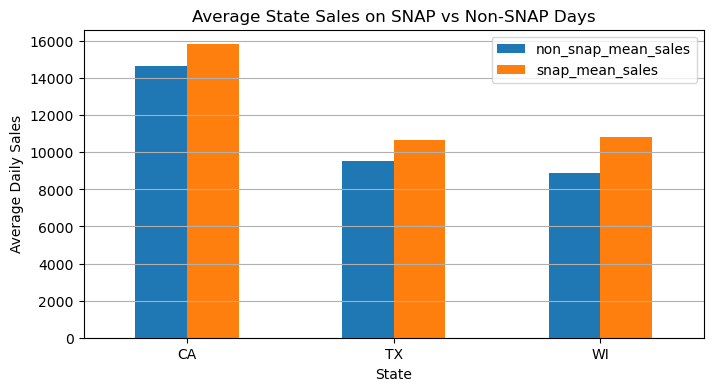

In [93]:
snap_plot_data = snap_summary.set_index("state")[["non_snap_mean_sales", "snap_mean_sales"]]

plt.figure(figsize=(8, 4))

snap_plot_data.plot(kind="bar", figsize=(8, 4))

plt.title("Average State Sales on SNAP vs Non-SNAP Days")
plt.xlabel("State")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig("../outputs/figures/snap_vs_non_snap_sales_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x400 with 0 Axes>

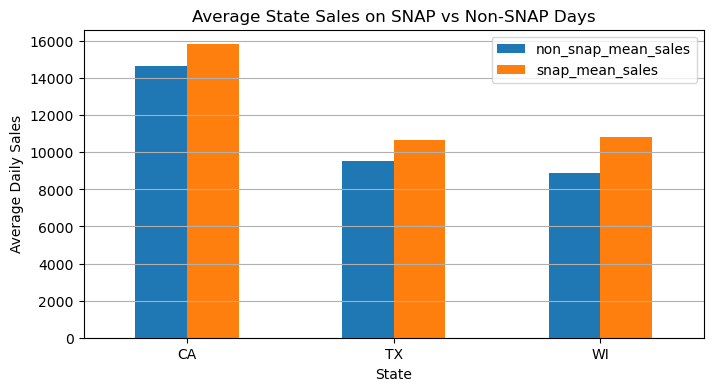

In [94]:
snap_plot_data = snap_summary.set_index("state")[["non_snap_mean_sales", "snap_mean_sales"]]

plt.figure(figsize=(8, 4))

snap_plot_data.plot(kind="bar", figsize=(8, 4))

plt.title("Average State Sales on SNAP vs Non-SNAP Days")
plt.xlabel("State")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig("../outputs/figures/snap_vs_non_snap_sales_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

## Event and SNAP Effects — Interpretation

The event analysis shows that most days in the calendar file do not contain a recorded event. This is expected because missing values in the event columns represent normal non-event days rather than data errors.

When comparing event and non-event days, average total sales are slightly lower on event days. Non-event days have an average total sales value of approximately 34,609 units, while event days have an average of approximately 33,030 units, representing a difference of around -4.56%. However, this result should be interpreted carefully because event days group together several different types of events. Therefore, this descriptive comparison does not imply that events cause lower sales.

The event type analysis shows that sales behaviour differs by event category. Sporting events have the highest average total sales, followed by Cultural and Religious events. National events have the lowest average sales among the event types. This suggests that a simple event/no-event feature may not fully capture the variation between different event types.

The individual event analysis also shows variation across named events. Events such as Labor Day, Orthodox Easter, Super Bowl, and Easter are associated with relatively high average sales. This indicates that event effects are heterogeneous, meaning that different events may be linked with different sales patterns.

The SNAP analysis shows a clearer pattern. SNAP days are associated with higher average sales in all three states. California shows an increase of approximately 7.95% on SNAP days, Texas shows an increase of approximately 11.52%, and Wisconsin shows the largest increase at approximately 21.82%. This suggests that SNAP indicators may provide useful predictive information for forecasting, especially when used in a state-specific way.

Overall, this analysis supports the inclusion of calendar, event, and SNAP-related features in later forecasting models. However, the results should be treated as descriptive associations rather than causal effects.


### Surprise Log

Event days are 4.56% lower than non-event days overall, but SNAP days are higher in every state: CA by 7.95%, TX by 11.52%, and WI by 21.82%.

This finding will be revisited after demand classification in Step 11.

# Step 7: Raw Price Analysis

In this section, I explore the sell prices file to understand price levels, price differences across categories and departments, and how often prices change over time. This is useful because price-related features may later be included in the forecasting models.

In [96]:
print("Prices shape:", prices.shape)

print("\nPrices columns:")
print(prices.columns.tolist())

print("\nNumber of unique stores in prices:", prices["store_id"].nunique())
print("Number of unique items in prices:", prices["item_id"].nunique())
print("Number of unique weeks in prices:", prices["wm_yr_wk"].nunique())

print("\nFirst 5 rows:")
prices.head()

Prices shape: (6841121, 4)

Prices columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

Number of unique stores in prices: 10
Number of unique items in prices: 3049
Number of unique weeks in prices: 282

First 5 rows:


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [97]:
price_summary = prices["sell_price"].describe()

price_summary

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [98]:
print("Minimum price:", prices["sell_price"].min())
print("Maximum price:", prices["sell_price"].max())
print("Average price:", round(prices["sell_price"].mean(), 2))
print("Median price:", round(prices["sell_price"].median(), 2))

Minimum price: 0.01
Maximum price: 107.32
Average price: 4.41
Median price: 3.47


In [99]:
store_price_summary = (
    prices.groupby("store_id")["sell_price"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .sort_values("mean", ascending=False)
)

store_price_summary

,count,mean,median,min,max
store_id,,,,,
WI_1,665912,4.457712,3.48,0.01,35.88
CA_2,637395,4.445500,3.48,0.20,30.98
WI_2,678171,4.441717,3.47,0.05,61.46
CA_4,679025,4.421580,3.47,0.01,30.98
WI_3,696094,4.418117,3.47,0.01,107.32
CA_1,698412,4.414233,3.47,0.01,30.98
CA_3,693990,4.388229,3.44,0.01,30.98
TX_3,691112,4.387365,3.44,0.02,30.98
TX_1,699796,4.374569,3.42,0.05,52.62


In [100]:
# Create item metadata from sales file
item_metadata = sales[["item_id", "dept_id", "cat_id"]].drop_duplicates()

print("Item metadata shape:", item_metadata.shape)
item_metadata.head()

Item metadata shape: (3049, 3)


,item_id,dept_id,cat_id
0,HOBBIES_1_001,HOBBIES_1,HOBBIES
1,HOBBIES_1_002,HOBBIES_1,HOBBIES
2,HOBBIES_1_003,HOBBIES_1,HOBBIES
3,HOBBIES_1_004,HOBBIES_1,HOBBIES
4,HOBBIES_1_005,HOBBIES_1,HOBBIES


In [101]:
prices_with_meta = prices.merge(
    item_metadata,
    on="item_id",
    how="left"
)

print("Prices with metadata shape:", prices_with_meta.shape)

print("\nMissing values after merge:")
print(prices_with_meta[["dept_id", "cat_id"]].isnull().sum())

prices_with_meta.head()

Prices with metadata shape: (6841121, 6)

Missing values after merge:
dept_id    0
cat_id     0
dtype: int64


,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id
0,CA_1,HOBBIES_1_001,11325,9.58,HOBBIES_1,HOBBIES
1,CA_1,HOBBIES_1_001,11326,9.58,HOBBIES_1,HOBBIES
2,CA_1,HOBBIES_1_001,11327,8.26,HOBBIES_1,HOBBIES
3,CA_1,HOBBIES_1_001,11328,8.26,HOBBIES_1,HOBBIES
4,CA_1,HOBBIES_1_001,11329,8.26,HOBBIES_1,HOBBIES


In [102]:
category_price_summary = (
    prices_with_meta.groupby("cat_id")["sell_price"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .sort_values("mean", ascending=False)
)

category_price_summary

,count,mean,median,min,max
cat_id,,,,,
HOUSEHOLD,2375427,5.465780,4.94,0.01,107.32
HOBBIES,1283905,5.333896,3.97,0.01,30.98
FOODS,3181789,3.251027,2.68,0.01,19.48


In [103]:
department_price_summary = (
    prices_with_meta.groupby("dept_id")["sell_price"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .sort_values("mean", ascending=False)
)

department_price_summary

,count,mean,median,min,max
dept_id,,,,,
HOBBIES_1,960337,6.225784,4.88,0.01,30.98
HOUSEHOLD_2,1215130,5.855558,5.64,0.05,107.32
HOUSEHOLD_1,1160297,5.057583,3.97,0.01,29.97
FOODS_2,823305,4.084008,2.98,0.20,13.98
FOODS_1,523214,3.374649,2.54,0.07,12.98
FOODS_3,1835270,2.842107,2.50,0.01,19.48
HOBBIES_2,323568,2.686807,2.47,0.05,9.97


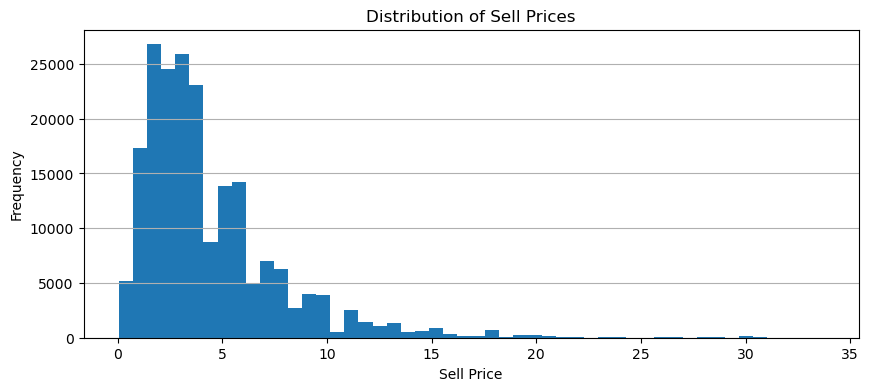

In [104]:
price_sample = prices_with_meta.sample(
    n=min(200000, len(prices_with_meta)),
    random_state=42
)

plt.figure(figsize=(10, 4))

plt.hist(price_sample["sell_price"], bins=50)

plt.title("Distribution of Sell Prices")
plt.xlabel("Sell Price")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

<Figure size 800x500 with 0 Axes>

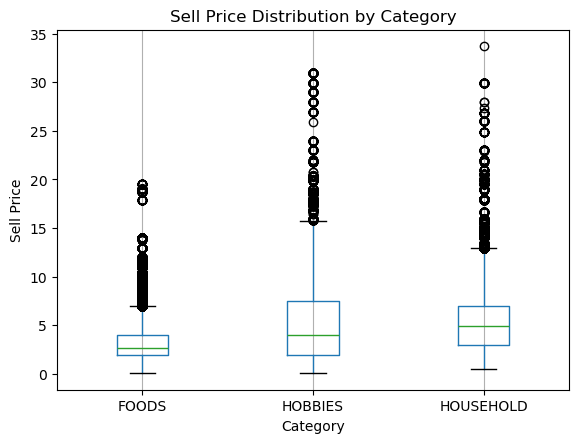

In [105]:
plt.figure(figsize=(8, 5))

price_sample.boxplot(column="sell_price", by="cat_id")

plt.title("Sell Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Sell Price")
plt.grid(axis="y")
plt.show()

In [106]:
# Sort prices by item-store-week
prices_sorted = prices_with_meta.sort_values(
    ["store_id", "item_id", "wm_yr_wk"]
).copy()

# Previous week's price for the same item-store
prices_sorted["previous_price"] = (
    prices_sorted.groupby(["store_id", "item_id"])["sell_price"]
    .shift(1)
)

# Flag whether price changed compared with previous available week
prices_sorted["price_changed"] = (
    (prices_sorted["sell_price"] != prices_sorted["previous_price"]) &
    (prices_sorted["previous_price"].notna())
).astype(int)

prices_sorted[[
    "store_id",
    "item_id",
    "wm_yr_wk",
    "sell_price",
    "previous_price",
    "price_changed"
]].head(10)

,store_id,item_id,wm_yr_wk,sell_price,previous_price,price_changed
368746,CA_1,FOODS_1_001,11101,2.0,NaN,0
368747,CA_1,FOODS_1_001,11102,2.0,2.0,0
368748,CA_1,FOODS_1_001,11103,2.0,2.0,0
368749,CA_1,FOODS_1_001,11104,2.0,2.0,0
368750,CA_1,FOODS_1_001,11105,2.0,2.0,0
368751,CA_1,FOODS_1_001,11106,2.0,2.0,0
368752,CA_1,FOODS_1_001,11107,2.0,2.0,0
368753,CA_1,FOODS_1_001,11108,2.0,2.0,0
368754,CA_1,FOODS_1_001,11109,2.0,2.0,0
368755,CA_1,FOODS_1_001,11110,2.0,2.0,0


In [107]:
overall_price_change_rate = prices_sorted["price_changed"].mean() * 100

print("Overall price change rate:", round(overall_price_change_rate, 2), "%")

Overall price change rate: 1.15 %


In [108]:
price_change_by_category = (
    prices_sorted.groupby("cat_id")["price_changed"]
    .agg(count="count", total_price_changes="sum", price_change_rate="mean")
)

price_change_by_category["price_change_rate"] = (
    price_change_by_category["price_change_rate"] * 100
)

price_change_by_category = price_change_by_category.sort_values(
    "price_change_rate",
    ascending=False
)

price_change_by_category

,count,total_price_changes,price_change_rate
cat_id,,,
FOODS,3181789,51456,1.617203
HOUSEHOLD,2375427,17887,0.753001
HOBBIES,1283905,9472,0.737749


In [109]:
price_change_by_department = (
    prices_sorted.groupby("dept_id")["price_changed"]
    .agg(count="count", total_price_changes="sum", price_change_rate="mean")
)

price_change_by_department["price_change_rate"] = (
    price_change_by_department["price_change_rate"] * 100
)

price_change_by_department = price_change_by_department.sort_values(
    "price_change_rate",
    ascending=False
)

price_change_by_department

,count,total_price_changes,price_change_rate
dept_id,,,
FOODS_2,823305,16770,2.036912
FOODS_1,523214,8254,1.577557
FOODS_3,1835270,26432,1.440224
HOUSEHOLD_1,1160297,10132,0.873225
HOBBIES_1,960337,7746,0.806592
HOUSEHOLD_2,1215130,7755,0.638203
HOBBIES_2,323568,1726,0.533427


In [110]:
price_variability = (
    prices_sorted.groupby(["store_id", "item_id"])["sell_price"]
    .agg(price_min="min", price_max="max", price_mean="mean", price_std="std", num_weeks="count")
    .reset_index()
)

price_variability["relative_price_range_percent"] = (
    (price_variability["price_max"] - price_variability["price_min"])
    / price_variability["price_mean"]
) * 100

price_variability = price_variability.merge(
    item_metadata,
    on="item_id",
    how="left"
)

price_variability.sort_values("relative_price_range_percent", ascending=False).head(10)

,store_id,item_id,price_min,price_max,price_mean,price_std,num_weeks,relative_price_range_percent,dept_id,cat_id
30379,WI_3,HOUSEHOLD_2_406,3.26,107.32,13.115872,9.965195,281,793.389878,HOUSEHOLD_2,HOUSEHOLD
14907,TX_1,HOUSEHOLD_2_178,3.00,44.36,7.365714,3.914082,273,561.520559,HOUSEHOLD_2,HOUSEHOLD
19616,TX_3,FOODS_3_711,0.05,1.00,0.195806,0.059464,279,485.172982,FOODS_3,FOODS
27174,WI_2,HOUSEHOLD_2_250,3.36,34.18,7.314504,2.188924,282,421.354639,HOUSEHOLD_2,HOUSEHOLD
24125,WI_1,HOUSEHOLD_2_250,4.97,30.32,7.046135,1.401025,282,359.771717,HOUSEHOLD_2,HOUSEHOLD
15194,TX_1,HOUSEHOLD_2_466,6.46,52.62,12.910214,12.583713,280,357.546350,HOUSEHOLD_2,HOUSEHOLD
27330,WI_2,HOUSEHOLD_2_406,12.46,61.46,15.505142,10.860842,282,316.024197,HOUSEHOLD_2,HOUSEHOLD
25629,WI_2,FOODS_3_625,2.50,11.25,3.025395,0.548143,228,289.218458,FOODS_3,FOODS
30223,WI_3,HOUSEHOLD_2_250,6.96,23.62,7.320390,2.162180,282,227.583501,HOUSEHOLD_2,HOUSEHOLD
24281,WI_1,HOUSEHOLD_2_406,9.97,35.88,12.635567,1.988982,282,205.056087,HOUSEHOLD_2,HOUSEHOLD


In [111]:
category_price_variability = (
    price_variability.groupby("cat_id")["relative_price_range_percent"]
    .agg(mean="mean", median="median", min="min", max="max")
    .sort_values("mean", ascending=False)
)

category_price_variability

,mean,median,min,max
cat_id,,,,
FOODS,17.743402,12.531662,0.0,485.172982
HOUSEHOLD,11.565214,4.580382,0.0,793.389878
HOBBIES,11.364166,6.139296,0.0,190.073105


In [112]:
store_price_summary.to_csv("../outputs/tables/store_price_summary.csv")
category_price_summary.to_csv("../outputs/tables/category_price_summary.csv")
department_price_summary.to_csv("../outputs/tables/department_price_summary.csv")
price_change_by_category.to_csv("../outputs/tables/price_change_by_category.csv")
price_change_by_department.to_csv("../outputs/tables/price_change_by_department.csv")
category_price_variability.to_csv("../outputs/tables/category_price_variability.csv")

print("Step 7 price analysis tables saved successfully.")

Step 7 price analysis tables saved successfully.


## Step 7A Interpretation

The sell prices file contains 6,841,121 records across 10 stores, 3,049 items and 282 Walmart weeks. Each record gives the weekly selling price for one item-store combination.

Most prices are low to moderate. The mean selling price is 4.41, while the median is 3.47. The maximum price is 107.32, so the price distribution is right-skewed, with a small number of high-price products.

Average prices are similar across stores. Store-level mean prices range from 4.37 in TX_2 to 4.46 in WI_1, so large store-level price differences are not clear at the aggregate level.

Category-level price differences are clearer. HOUSEHOLD has the highest average selling price at 5.47, followed by HOBBIES at 5.33 and FOODS at 3.25. This is useful because FOODS has the highest sales volume but the lowest average price.

Weekly price changes are rare overall. Only 1.15% of weekly price records show a change from the previous available week for the same item-store combination. FOODS has the highest price-change rate at 1.62%, compared with 0.75% for HOUSEHOLD and 0.74% for HOBBIES.

At department level, the highest price-change rates appear in FOODS_2 at 2.04%, FOODS_1 at 1.58%, and FOODS_3 at 1.44%. This means price changes are more common in FOODS departments than in HOUSEHOLD or HOBBIES departments.

Some item-store combinations have very large relative price ranges. The largest example is WI_3 / HOUSEHOLD_2_406, with a relative price range of 793.39%. These cases should not be removed at this stage, but they should be checked later when modelling.

This raw price analysis supports the inclusion of price-related features later, such as current selling price, price change, and relative price measures. This finding will be revisited after demand classification in Step 11.


### Note for later analysis

This is only the raw price analysis. A second price analysis will be completed after Step 11, once demand types have been created using ADI and CV². That later analysis will check whether price behaviour differs across smooth, erratic, intermittent, and lumpy demand series.

### Surprise Log

Weekly price changes are rare overall at 1.15%, but FOODS has the highest price-change rate at 1.62%, compared with 0.75% for HOUSEHOLD and 0.74% for HOBBIES.

This finding will be revisited after demand classification in Step 11.

# Step 8: Zero-Sales and Sparsity Analysis

In this section, I examine how common zero-sales observations are across the Walmart M5 item-store series. This step checks whether sparsity differs by category, state, and store before formal demand-type classification is created in Step 11.

In [118]:
total_observations = sales[sales_day_columns].size
zero_observations = (sales[sales_day_columns] == 0).sum().sum()
non_zero_observations = total_observations - zero_observations

zero_rate = zero_observations / total_observations * 100
non_zero_rate = non_zero_observations / total_observations * 100

print("Total item-store-day observations:", total_observations)
print("Zero observations:", zero_observations)
print("Non-zero observations:", non_zero_observations)
print("Zero rate:", round(zero_rate, 2), "%")
print("Non-zero rate:", round(non_zero_rate, 2), "%")

Total item-store-day observations: 59181090
Zero observations: 40241819
Non-zero observations: 18939271
Zero rate: 68.0 %
Non-zero rate: 32.0 %


In [120]:
sales["zero_count"] = (sales[sales_day_columns] == 0).sum(axis=1)
sales["non_zero_count"] = (sales[sales_day_columns] > 0).sum(axis=1)
sales["zero_rate_percent"] = sales["zero_count"] / len(sales_day_columns) * 100

series_sparsity_summary = sales["zero_rate_percent"].describe()

series_sparsity_summary

count    30490.000000
mean        67.997766
std         22.340622
min          0.154560
25%         53.477589
50%         73.312725
75%         86.501803
max         99.381762
Name: zero_rate_percent, dtype: float64

In [122]:
print("Average series zero rate:", round(sales["zero_rate_percent"].mean(), 2), "%")
print("Median series zero rate:", round(sales["zero_rate_percent"].median(), 2), "%")
print("Minimum series zero rate:", round(sales["zero_rate_percent"].min(), 2), "%")
print("Maximum series zero rate:", round(sales["zero_rate_percent"].max(), 2), "%")

Average series zero rate: 68.0 %
Median series zero rate: 73.31 %
Minimum series zero rate: 0.15 %
Maximum series zero rate: 99.38 %


In [124]:
def sparsity_bucket(zero_rate):
    if zero_rate == 0:
        return "0% zero days"
    elif zero_rate <= 25:
        return "0-25% zero days"
    elif zero_rate <= 50:
        return "25-50% zero days"
    elif zero_rate <= 75:
        return "50-75% zero days"
    elif zero_rate <= 90:
        return "75-90% zero days"
    else:
        return ">90% zero days"

sales["sparsity_bucket"] = sales["zero_rate_percent"].apply(sparsity_bucket)

sparsity_bucket_counts = (
    sales["sparsity_bucket"]
    .value_counts()
    .reindex([
        "0% zero days",
        "0-25% zero days",
        "25-50% zero days",
        "50-75% zero days",
        "75-90% zero days",
        ">90% zero days"
    ])
)

sparsity_bucket_percent = sparsity_bucket_counts / len(sales) * 100

sparsity_bucket_summary = pd.DataFrame({
    "series_count": sparsity_bucket_counts,
    "percentage": sparsity_bucket_percent.round(2)
})

sparsity_bucket_summary

,series_count,percentage
sparsity_bucket,,
0% zero days,NaN,NaN
0-25% zero days,1572.0,5.16
25-50% zero days,5066.0,16.62
50-75% zero days,9450.0,30.99
75-90% zero days,9269.0,30.40
>90% zero days,5133.0,16.84


In [125]:
category_sparsity = (
    sales.groupby("cat_id")
    .agg(
        series_count=("id", "count"),
        avg_zero_rate=("zero_rate_percent", "mean"),
        median_zero_rate=("zero_rate_percent", "median"),
        avg_total_sales=("total_sales", "mean")
    )
    .sort_values("avg_zero_rate", ascending=False)
)

category_sparsity

,series_count,avg_zero_rate,median_zero_rate,avg_total_sales
cat_id,,,,
HOBBIES,5650,77.149166,83.049974,1104.540885
HOUSEHOLD,10470,71.602198,77.331273,1410.132760
FOODS,14370,61.773422,64.966512,3195.715170


In [127]:
department_sparsity = (
    sales.groupby("dept_id")
    .agg(
        series_count=("id", "count"),
        avg_zero_rate=("zero_rate_percent", "mean"),
        median_zero_rate=("zero_rate_percent", "median"),
        avg_total_sales=("total_sales", "mean")
    )
    .sort_values("avg_zero_rate", ascending=False)
)

department_sparsity

,series_count,avg_zero_rate,median_zero_rate,avg_total_sales
dept_id,,,,
HOBBIES_2,1490,88.358281,90.314271,363.518121
HOUSEHOLD_2,5150,80.615497,84.441010,590.531456
HOBBIES_1,4160,73.134363,78.104070,1369.955288
FOODS_2,3980,67.778472,72.024730,1958.548995
FOODS_1,2160,62.985813,64.657393,2402.962963
HOUSEHOLD_1,5320,62.876918,66.357548,2203.543797
FOODS_3,8230,58.551203,61.823802,4002.065857


In [129]:
state_sparsity = (
    sales.groupby("state_id")
    .agg(
        series_count=("id", "count"),
        avg_zero_rate=("zero_rate_percent", "mean"),
        median_zero_rate=("zero_rate_percent", "median"),
        avg_total_sales=("total_sales", "mean")
    )
    .sort_values("avg_zero_rate", ascending=False)
)

state_sparsity

,series_count,avg_zero_rate,median_zero_rate,avg_total_sales
state_id,,,,
WI,9147,69.755238,74.961360,2022.745272
TX,9147,68.914440,74.703761,2102.154258
CA,12196,65.992156,70.685214,2393.958429


In [131]:
store_sparsity = (
    sales.groupby("store_id")
    .agg(
        series_count=("id", "count"),
        avg_zero_rate=("zero_rate_percent", "mean"),
        median_zero_rate=("zero_rate_percent", "median"),
        avg_total_sales=("total_sales", "mean")
    )
    .sort_values("avg_zero_rate", ascending=False)
)

store_sparsity

,series_count,avg_zero_rate,median_zero_rate,avg_total_sales
store_id,,,,
CA_4,3049,71.999519,77.331273,1371.772384
TX_1,3049,70.714074,76.919114,1867.111512
WI_2,3049,70.480047,75.888717,2196.781896
WI_3,3049,70.031610,75.837197,2145.804198
TX_3,3049,69.715073,75.734158,2035.401771
CA_2,3049,68.810291,74.188563,1908.296163
WI_1,3049,68.754056,72.900567,1725.649721
TX_2,3049,66.314172,71.406491,2403.949492
CA_1,3049,63.759049,68.109222,2568.792391


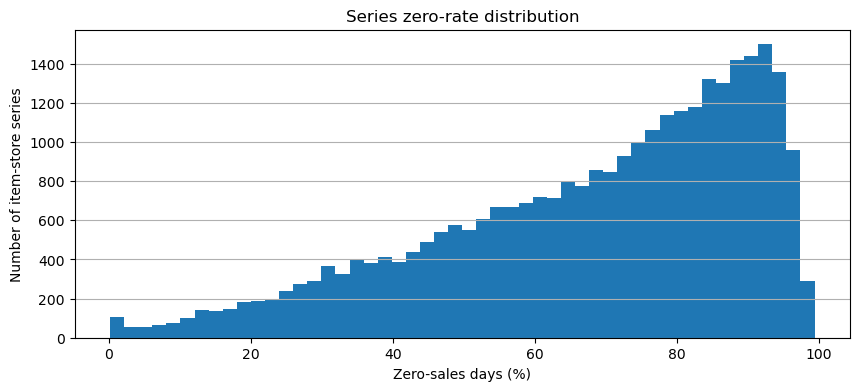

In [142]:
plt.figure(figsize=(10, 4))

plt.hist(sales["zero_rate_percent"], bins=50)

plt.title("Series zero-rate distribution")
plt.xlabel("Zero-sales days (%)")
plt.ylabel("Number of item-store series")
plt.grid(axis="y")
plt.show()

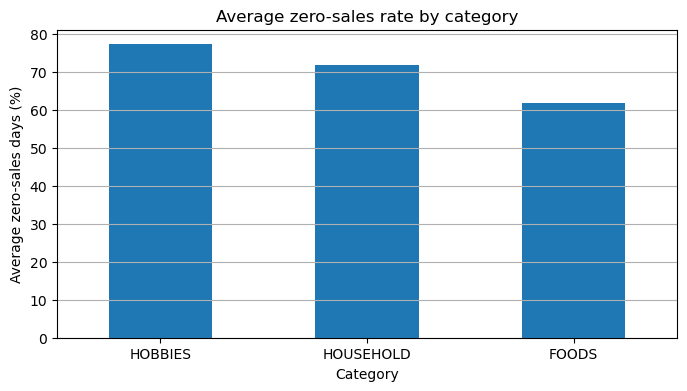

In [143]:
plt.figure(figsize=(8, 4))

category_sparsity["avg_zero_rate"].plot(kind="bar")

plt.title("Average zero-sales rate by category")
plt.xlabel("Category")
plt.ylabel("Average zero-sales days (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [140]:
def trailing_zero_count(row):
    values = row[sales_day_columns].values
    count = 0
    
    for value in values[::-1]:
        if value == 0:
            count += 1
        else:
            break
    
    return count

sales["trailing_zero_count"] = sales.apply(trailing_zero_count, axis=1)
sales["trailing_zero_percent"] = sales["trailing_zero_count"] / len(sales_day_columns) * 100

print("Average trailing zero days:", round(sales["trailing_zero_count"].mean(), 2))
print("Median trailing zero days:", round(sales["trailing_zero_count"].median(), 2))
print("Maximum trailing zero days:", sales["trailing_zero_count"].max())

Average trailing zero days: 4.13
Median trailing zero days: 0.0
Maximum trailing zero days: 1690


In [141]:
structural_zero_90_days = (sales["trailing_zero_count"] >= 90).sum()
structural_zero_180_days = (sales["trailing_zero_count"] >= 180).sum()
structural_zero_365_days = (sales["trailing_zero_count"] >= 365).sum()

print("Series with at least 90 trailing zero days:", structural_zero_90_days)
print("Percentage:", round(structural_zero_90_days / len(sales) * 100, 2), "%")

print("\nSeries with at least 180 trailing zero days:", structural_zero_180_days)
print("Percentage:", round(structural_zero_180_days / len(sales) * 100, 2), "%")

print("\nSeries with at least 365 trailing zero days:", structural_zero_365_days)
print("Percentage:", round(structural_zero_365_days / len(sales) * 100, 2), "%")

Series with at least 90 trailing zero days: 163
Percentage: 0.53 %

Series with at least 180 trailing zero days: 64
Percentage: 0.21 %

Series with at least 365 trailing zero days: 9
Percentage: 0.03 %


In [137]:
# Series with high zero rate but without long ending zero block
intermittent_zero_series = sales[
    (sales["zero_rate_percent"] > 50) &
    (sales["trailing_zero_count"] < 90)
]

print("Series with >50% zero days and <90 trailing zero days:", len(intermittent_zero_series))
print("Percentage:", round(len(intermittent_zero_series) / len(sales) * 100, 2), "%")

Series with >50% zero days and <90 trailing zero days: 23696
Percentage: 77.72 %


In [138]:
def spike_adjacent_zero_count(row):
    values = row[sales_day_columns].values.astype(float)
    
    non_zero_values = values[values > 0]
    if len(non_zero_values) < 10:
        return 0
    
    threshold = non_zero_values.mean() + 3 * non_zero_values.std()
    spike_positions = np.where(values > threshold)[0]
    
    count = 0
    
    for pos in spike_positions:
        before_zero = pos > 0 and values[pos - 1] == 0
        after_zero = pos < len(values) - 1 and values[pos + 1] == 0
        
        if before_zero or after_zero:
            count += 1
    
    return count

sales["spike_adjacent_zero_count"] = sales.apply(spike_adjacent_zero_count, axis=1)

series_with_spike_adjacent_zeros = (sales["spike_adjacent_zero_count"] > 0).sum()

print("Series with at least one spike-adjacent zero:", series_with_spike_adjacent_zeros)
print("Percentage:", round(series_with_spike_adjacent_zeros / len(sales) * 100, 2), "%")

Series with at least one spike-adjacent zero: 28053
Percentage: 92.01 %


In [144]:
zero_pattern_summary = pd.DataFrame({
    "pattern": [
        "Possible structural zeros: >=90 trailing zero days",
        "Possible intermittent zeros: >50% zero days and <90 trailing zero days",
        "Possible spike-adjacent zeros: at least one zero next to demand spike"
    ],
    "series_count": [
        structural_zero_90_days,
        len(intermittent_zero_series),
        series_with_spike_adjacent_zeros
    ]
})

zero_pattern_summary["percentage"] = (
    zero_pattern_summary["series_count"] / len(sales) * 100
).round(2)

zero_pattern_summary

,pattern,series_count,percentage
0,Possible structural zeros: >=90 trailing zero ...,163,0.53
1,Possible intermittent zeros: >50% zero days an...,23696,77.72
2,Possible spike-adjacent zeros: at least one ze...,28053,92.01


These zero pattern groups are exploratory flags, not mutually exclusive classes. A series can appear in more than one pattern group.

## Zero-Sales and Sparsity — Interpretation

The dataset contains 59,181,090 item-store-day observations. Out of these, 40,241,819 observations are zero, giving an overall zero-sales rate of 68.0%. Only 18,939,271 observations are non-zero sales. This means most item-store-day records in the dataset contain no sales.

At series level, the average zero-sales rate is 68.0%, while the median zero-sales rate is 73.31%. The median is higher than the mean, which means the typical item-store series is even more sparse than the overall average suggests. The least sparse series has zero sales on only 0.15% of days, while the most sparse series has zero sales on 99.38% of days.

The sparsity bucket analysis shows that 23,852 out of 30,490 series have zero sales on more than half of the observed days. This is 78.23% of all item-store series. Only 1,572 series have zero sales on 25% or fewer days. This means most item-store series cannot be treated as regular daily demand.

Sparsity differs by category. HOBBIES has the highest average zero-sales rate at 77.15%, followed by HOUSEHOLD at 71.60% and FOODS at 61.77%. FOODS has the highest sales volume from the earlier analysis, but it is also the least sparse category. HOBBIES has lower sales volume and more zero-sales days.

At department level, HOBBIES_2 has the highest average zero-sales rate at 88.36%, while FOODS_3 has the lowest at 58.55%. This shows that the forecasting difficulty can change depending on the product department.

State-level sparsity also differs. Wisconsin has the highest average zero-sales rate at 69.76%, followed by Texas at 68.91% and California at 65.99%. California also has the highest average total sales per series at 2,393.96 units.

At store level, CA_4 has the highest average zero-sales rate at 72.00%, while CA_3 has the lowest at 59.40%. This matches the earlier sales-volume analysis, where CA_3 was one of the strongest stores and CA_4 was one of the weakest.

The trailing-zero analysis shows that possible structural-zero series are rare. Only 163 series have at least 90 zero-sales days at the end of the time series, which is 0.53% of all series. Only 64 series have at least 180 trailing zero days, and only 9 series have at least 365 trailing zero days. This means most zero-sales behaviour is not simply caused by products disappearing at the end of the dataset.

The stronger pattern is intermittent-looking sparsity. There are 23,696 series with more than 50% zero-sales days and fewer than 90 trailing zero days. This is 77.72% of all item-store series. These zeros are more likely to be scattered through the time series rather than concentrated only at the end.

The spike-adjacent zero flag identifies 28,053 series, or 92.01% of all series. This number is very high, so I will treat it only as a rough exploratory flag. It should not be interpreted as direct evidence of stockouts or promotion effects without checking individual product-store series.

These results support the later use of a zero-aware modelling approach. For XGBoost, a Tweedie objective is a reasonable candidate because the dataset has 68.0% zero observations and many positive sales values when demand occurs. However, this choice will be tested during modelling rather than assumed to be best.

Demand type classification in Step 11 will allow these sparsity patterns to be linked directly to the ADI/CV² taxonomy.


## Link to Next Stage

Step 8 confirms that sparsity is a central issue in the dataset, with 68.0% zero-sales observations and 78.23% of item-store series having zero sales on more than half of the days.

However, these are still aggregate sparsity results. The next major analytical step is to classify item-store series into demand types using ADI and CV². From that point onward, all analysis will be broken down by smooth, erratic, intermittent, and lumpy demand.

### Surprise Log

The most useful finding is that possible structural-zero series are rare: only 163 series, or 0.53%, have at least 90 trailing zero days. The main issue is not discontinued-looking products. It is scattered sparsity, with 23,696 series, or 77.72%, having more than 50% zero days but fewer than 90 trailing zero days.

# Updated Scope After Supervisor Feedback

After supervisor feedback and the Chapter 1 draft, the project scope has been updated.

The core dissertation will compare a seasonal naive baseline and XGBoost across demand types classified using ADI and CV². WRMSSE will be used as the primary evaluation metric, with MAE used as a secondary metric for interpretation.

From Step 13 onward, all analysis and results will be reported by demand type: smooth, erratic, intermittent, and lumpy.

The ablation study will be run separately within each demand type. The main ablation output will compare WRMSSE changes for each feature group across smooth, erratic, intermittent, and lumpy demand.

SHAP will be used to explain the XGBoost model. An LSTM will be included as a targeted feasibility study, not as the main model.

Additional final outputs will include a Forecastability Index, Product Biographies, and a Practitioner Decision Matrix.